# Automatic Classification of Javanese Gamelan Forms — Dataset Comparison

This notebook compares **three datasets** under a **unified evaluation protocol** (Leave-One-Out / Leave-One-Group-Out CV for all six models):

| Dataset | Size | Class balance | Directory | CV Method |
|---------|------|---------------|-----------|-----------|
| **Original** | 35 pieces (5 per genre) | Uniform | `dataset/` | LOOCV (35 folds) |
| **Augmented Balanced** | 77 pieces (11 per genre) | Uniform | `dataset_augmented_balanced/` | LOGOCV (35 folds) |
| **Augmented Unbalanced** | 192 pieces (11–45 per genre) | Skewed | `dataset_augmented/` | LOGOCV (35 folds) |

Each of the 35 original compositions is transposed by ±1–7 scale degrees within the Kepatihan system. The **balanced** variant caps every genre to the minimum natural yield (11 pieces). The **unbalanced** variant retains all valid transpositions, using class weighting to compensate. All three evaluations use **35 folds** where each fold holds out one original piece (and all its transpositions), making results directly comparable.

**Forms classified (7 classes):** Ayak-Ayak, Bubaran, Ketawang, Ladrang, Lancaran, Sampak, Srepegan

All core logic lives in the `src/` package — this notebook orchestrates the pipeline and visualises results.

## Table of Contents

1. [Setup & Dependencies](#1-setup)
2. [Dataset Overview](#2-dataset)
3. [PDF Parsing & Feature Extraction](#3-parsing)
4. [Exploratory Data Analysis](#4-eda)
5. [Evaluation Protocol](#5-protocol)
6. [Model 1 — Decision Tree](#6-dt)
7. [Model 2 — Random Forest](#7-rf)
8. [Model 3 — Support Vector Machine](#8-svm)
9. [Model 4 — k-Nearest Neighbors](#9-knn)
10. [Model 5 — MLP (Neural Network)](#10-mlp)
11. [Model 6 — 1D CNN](#11-cnn)
12. [Three-Way Dataset Comparison](#12-comparison)
13. [Conclusions](#13-conclusions)

---
## 1. Setup & Dependencies <a id='1-setup'></a>

In [1]:
import warnings
warnings.filterwarnings("ignore")

import math
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, f1_score,
)
from sklearn.model_selection import cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight

import torch

# ── Project modules ──────────────────────────────────────────────────────────
from src.parser import Note, extract_raw_text, parse_notation, pad_or_truncate, N_DIMS
from src.features import extract_features, FEATURE_NAMES, N_FEATURES
from src.data import (
    load_corpus_features, load_corpus_sequences,
    stratified_split, to_arrays, to_tensors,
    get_logo_groups,
)
from src.statistical_analysis import (
    load_corpus as load_corpus_parsed, aggregate, all_notes, genre_colors,
)
from src.gamelan_mlp import GamelanMLP, train as train_mlp
from src.gamelan_cnn import GamelanCNN, train_model as train_cnn
from src.plots import plot_embedding_pca

torch.manual_seed(42)
np.random.seed(42)

%matplotlib inline
plt.rcParams.update({"figure.facecolor": "#FAFAF8", "axes.facecolor": "#F8F5F0", "font.size": 10})

PALETTE = ["#E63946", "#457B9D", "#2A9D8F", "#E9C46A", "#F4A261", "#264653", "#A8DADC", "#9B2335"]

DATASET_ORIG  = Path("dataset")
DATASET_BAL   = Path("dataset_augmented_balanced")
DATASET_UNBAL = Path("dataset_augmented")
DATASET_ROOT  = DATASET_BAL  # primary experiment uses the balanced dataset

print(f"Original   : {DATASET_ORIG.resolve()}  (exists: {DATASET_ORIG.exists()})")
print(f"Balanced   : {DATASET_BAL.resolve()}  (exists: {DATASET_BAL.exists()})")
print(f"Unbalanced : {DATASET_UNBAL.resolve()}  (exists: {DATASET_UNBAL.exists()})")
print(f"Primary    : {DATASET_ROOT.name}")

Original   : /home/frederic/Documents/UPF/semester2/Symbolic/classifying-javanese-gamelan-forms/dataset  (exists: True)
Balanced   : /home/frederic/Documents/UPF/semester2/Symbolic/classifying-javanese-gamelan-forms/dataset_augmented_balanced  (exists: True)
Unbalanced : /home/frederic/Documents/UPF/semester2/Symbolic/classifying-javanese-gamelan-forms/dataset_augmented  (exists: True)
Primary    : dataset_augmented_balanced


---
## 2. Dataset Overview <a id='2-dataset'></a>

Both augmented datasets are derived from 35 original compositions (Kurniawati et al., *Data in Brief*, 2024) via **pitch transposition**: each piece is shifted by ±1 to ±7 scale degrees within the 7-tone Kepatihan system.

- **Unbalanced (192 pieces):** Retains all valid transpositions. Class sizes range from 11 (Ayak-Ayak) to 45 (Sampak).
- **Balanced (77 pieces):** Caps every genre to the minimum natural yield (11 pieces), ensuring uniform class sizes.

The cell below shows statistics for the **primary (balanced)** dataset.

In [2]:
dataset_summary = []
for genre_dir in sorted(DATASET_ROOT.iterdir()):
    if not genre_dir.is_dir():
        continue
    for song_dir in sorted(genre_dir.iterdir()):
        if not song_dir.is_dir():
            continue
        main_pdf = song_dir / f"{song_dir.name}.pdf"
        dataset_summary.append({
            "Form (Bentuk)": genre_dir.name,
            "Song": song_dir.name,
            "Main PDF exists": main_pdf.exists(),
            "Total PDFs": len(list(song_dir.glob("*.pdf"))),
        })

df_dataset = pd.DataFrame(dataset_summary)
print(f"Total pieces: {len(df_dataset)}")
print(f"Forms: {df_dataset['Form (Bentuk)'].nunique()}")
print(f"\nPieces per form:")
print(df_dataset.groupby("Form (Bentuk)").size().to_string())
print()
df_dataset

Total pieces: 77
Forms: 7

Pieces per form:
Form (Bentuk)
Ayak Ayak    11
Bubaran      11
Ketawang     11
Ladrang      11
Lancaran     11
Sampak       11
Srepegan     11



,Form (Bentuk),Song,Main PDF exists,Total PDFs
0,Ayak Ayak,Ayak Ayak Manyura Slendro Manyura,True,1
1,Ayak Ayak,Ayak Ayak Manyura Slendro Manyura shift+1,True,1
2,Ayak Ayak,Ayak Ayak Nem Slendro Nem,True,1
3,Ayak Ayak,Ayak Ayak Nem Slendro Nem shift+1,True,1
4,Ayak Ayak,Ayak Ayak Nem Slendro Nem shift+2,True,1
...,...,...,...,...
72,Srepegan,Srepegan Nem Slendro Nem shift-2,True,1
73,Srepegan,Srepegan Nem Slendro Nem shift-3,True,1
74,Srepegan,Srepegan Sanga Slendro Sanga,True,1
75,Srepegan,Srepegan Tlutur Slendro Manyura,True,1


---
## 3. PDF Parsing & Feature Extraction <a id='3-parsing'></a>

The PDF scores use a custom **Balungan TrueType font** where each letter maps to a specific pitch and octave. Our parser (`src/parser.py`) decodes these glyphs into structured note events.

### 3.1 Parsing a single piece (demonstration)

In [3]:
demo_pdf = DATASET_ROOT / "Lancaran" / "Lancaran Manyar Sewu Slendro Manyura" / "Lancaran Manyar Sewu Slendro Manyura.pdf"
raw_text = extract_raw_text(str(demo_pdf))
parsed = parse_notation(raw_text)

print(f"Title : {parsed['title']}")
print(f"Laras : {parsed['laras']}")
print(f"Pathet: {parsed['pathet']}")
print(f"Sections: {len(parsed['sections'])}")
for sec in parsed["sections"]:
    notes = [n for n in sec["notes"] if isinstance(n, Note)]
    sounding = [n for n in notes if not n.is_rest]
    print(f"  {sec['name']:10s} — {len(notes)} events ({len(sounding)} sounding, {len(notes)-len(sounding)} rests)")

print(f"\nFeature vector ({N_FEATURES} dims):")
feats = extract_features(parsed)
for name, val in zip(FEATURE_NAMES, feats):
    print(f"  {name:25s} {val:.4f}")

Title : Lancaran Manyarséwu, laras sléndro pathet manyura
Laras : sléndro
Pathet: manyura
Sections: 1
  Buka       — 76 events (38 sounding, 38 rests)

Feature vector (29 dims):
  pitch_1_%                 0.1579
  pitch_2_%                 0.1053
  pitch_3_%                 0.2368
  pitch_4_%                 0.0000
  pitch_5_%                 0.2368
  pitch_6_%                 0.2632
  pitch_7_%                 0.0000
  reg_low_%                 0.0000
  reg_mid_%                 0.8421
  reg_high_%                0.1579
  marker_density            0.7632
  rest_ratio                0.5000
  step_ratio                0.6757
  leap_ratio                0.3243
  mean_abs_interval         2.5946
  gong_cycle_mean           15.2000
  gong_cycle_std            1.6000
  gong_cycle_count          5.0000
  has_repeat                1.0000
  repeat_count              1.0000
  has_Buka                  1.0000
  has_Merong                0.0000
  has_Inggah                0.0000
  has_Ngelik    

### 3.2 Load full corpus — feature extraction

Uses `src.data.load_corpus_features()` to parse all augmented PDFs and extract 29-dim feature vectors. Both the balanced and unbalanced corpora are loaded for later comparison.

In [4]:
print("═" * 60)
print("Loading ORIGINAL corpus (35 pieces)...\n")
records_orig = load_corpus_features(DATASET_ORIG)
print(f"\n  Loaded {len(records_orig)} pieces.")

X_feat_o, y_o, le_o = to_arrays(records_orig)
class_names_o = list(le_o.classes_)

print(f"  Samples per class: {[int((y_o == i).sum()) for i in range(len(class_names_o))]}")

print("\n" + "═" * 60)
print("Loading BALANCED corpus (77 pieces)...\n")
records = load_corpus_features(DATASET_BAL)
print(f"\n  Loaded {len(records)} pieces.")

X_feat, y, le = to_arrays(records)
class_names = list(le.classes_)
n_classes = len(class_names)

print(f"  Feature matrix shape: {X_feat.shape}")
print(f"  Classes ({n_classes}): {class_names}")
print(f"  Samples per class: {[int((y == i).sum()) for i in range(n_classes)]}")

print("\n" + "═" * 60)
print("Loading UNBALANCED corpus (192 pieces)...\n")
records_unbal = load_corpus_features(DATASET_UNBAL)
print(f"\n  Loaded {len(records_unbal)} pieces.")

X_feat_u, y_u, le_u = to_arrays(records_unbal)
class_names_u = list(le_u.classes_)

print(f"  Samples per class: {[int((y_u == i).sum()) for i in range(len(class_names_u))]}")

════════════════════════════════════════════════════════════
Loading ORIGINAL corpus (35 pieces)...

  ✅  Ayak Ayak / Ayak Ayak Manyura Slendro Manyura
  ✅  Ayak Ayak / Ayak Ayak Nem Slendro Nem
  ✅  Ayak Ayak / Ayak Ayak Pamungkas Slendro Manyura
  ✅  Ayak Ayak / Ayak Ayak Sanga Slendro Sanga
  ✅  Ayak Ayak / Ayak Ayak Umbul Donga Slendro Manyura
  ✅  Bubaran / Bubaran Arum Arum Pelog Barang
  ✅  Bubaran / Bubaran Kembang Pacar Pelog Nem
  ✅  Bubaran / Bubaran Purwaka Pelog Nem
  ✅  Bubaran / Bubaran Sembunggilang Slendro Sanga
  ✅  Bubaran / Bubaran Udan Mas Pelog Barang
  ✅  Ketawang / Ketawang Ibu Pretiwi Pelog Nem
  ✅  Ketawang / Ketawang Kinanthi Pawukir Slendro Manyura
  ✅  Ketawang / Ketawang Kinanthi Sandhung Slendro Manyura
  ✅  Ketawang / Ketawang Langen Gita Pelog Barang
  ✅  Ketawang / Ketawang Subakastawa Slendro Sanga
  ✅  Ladrang / Ladrang Kalongking Pelog Nem
  ✅  Ladrang / Ladrang Mugi Rahayu Slendro Manyura
  ✅  Ladrang / Ladrang Pariwisata Slendro Sanga
  ✅  Ladrang

### 3.3 Feature overview

In [5]:
df_features = pd.DataFrame(X_feat, columns=FEATURE_NAMES)
df_features["genre"] = [r["genre"] for r in records]
df_features["song"] = [r["song_name"] for r in records]

print("Feature statistics:")
df_features[FEATURE_NAMES].describe().round(3)

Feature statistics:


,pitch_1_%,pitch_2_%,pitch_3_%,pitch_4_%,pitch_5_%,pitch_6_%,pitch_7_%,reg_low_%,reg_mid_%,reg_high_%,...,repeat_count,has_Buka,has_Merong,has_Inggah,has_Ngelik,has_Umpak,has_Suwuk,pitch_entropy,ascending_ratio,direction_changes
count,77.000,77.000,77.000,77.000,77.000,77.000,77.000,77.000,77.000,77.000,...,77.000,77.000,77.0,77.0,77.000,77.0,77.000,77.000,77.000,77.000
mean,0.142,0.188,0.151,0.102,0.150,0.145,0.109,0.200,0.610,0.177,...,1.104,0.935,0.0,0.0,0.273,0.0,0.416,2.236,0.407,0.462
std,0.102,0.118,0.103,0.110,0.110,0.106,0.114,0.206,0.243,0.171,...,0.718,0.248,0.0,0.0,0.448,0.0,0.496,0.348,0.142,0.228
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.0,0.0,0.000,0.0,0.000,0.000,0.000,0.000
25%,0.062,0.101,0.070,0.000,0.062,0.085,0.000,0.048,0.464,0.037,...,1.000,1.000,0.0,0.0,0.000,0.0,0.000,2.164,0.405,0.344
50%,0.145,0.204,0.163,0.060,0.146,0.128,0.083,0.155,0.660,0.148,...,1.000,1.000,0.0,0.0,0.000,0.0,0.000,2.272,0.452,0.538
75%,0.215,0.272,0.232,0.202,0.232,0.204,0.181,0.298,0.758,0.261,...,1.000,1.000,0.0,0.0,1.000,0.0,1.000,2.433,0.475,0.634
max,0.429,0.429,0.429,0.429,0.429,0.429,0.429,0.959,1.000,0.652,...,7.000,1.000,0.0,0.0,1.000,0.0,1.000,2.598,0.548,0.811


---
## 4. Exploratory Data Analysis <a id='4-eda'></a>

Uses `src.statistical_analysis` to compute and visualise per-genre statistics.

In [6]:
print("Loading corpus (parsed notation for EDA)...\n")
corpus = load_corpus_parsed(DATASET_ROOT)
genre_stats = aggregate(corpus)
genres = sorted(genre_stats)
colors = genre_colors(genres)
print(f"\nGenres: {genres}")
for g in genres:
    s = genre_stats[g]
    print(f"  {g}: {s['n_pieces']} pieces, {s['total_notes']} notes")

Loading corpus (parsed notation for EDA)...

  ✅  Ayak Ayak / Ayak Ayak Manyura Slendro Manyura
  ✅  Ayak Ayak / Ayak Ayak Manyura Slendro Manyura shift+1
  ✅  Ayak Ayak / Ayak Ayak Nem Slendro Nem
  ✅  Ayak Ayak / Ayak Ayak Nem Slendro Nem shift+1
  ✅  Ayak Ayak / Ayak Ayak Nem Slendro Nem shift+2
  ✅  Ayak Ayak / Ayak Ayak Nem Slendro Nem shift+3
  ✅  Ayak Ayak / Ayak Ayak Nem Slendro Nem shift+4
  ✅  Ayak Ayak / Ayak Ayak Nem Slendro Nem shift-1
  ✅  Ayak Ayak / Ayak Ayak Pamungkas Slendro Manyura
  ✅  Ayak Ayak / Ayak Ayak Sanga Slendro Sanga
  ✅  Ayak Ayak / Ayak Ayak Umbul Donga Slendro Manyura
  ✅  Bubaran / Bubaran Arum Arum Pelog Barang
  ✅  Bubaran / Bubaran Arum Arum Pelog Barang shift+1
  ✅  Bubaran / Bubaran Arum Arum Pelog Barang shift+2
  ✅  Bubaran / Bubaran Arum Arum Pelog Barang shift+3
  ✅  Bubaran / Bubaran Arum Arum Pelog Barang shift+4
  ✅  Bubaran / Bubaran Arum Arum Pelog Barang shift+5
  ✅  Bubaran / Bubaran Arum Arum Pelog Barang shift+6
  ✅  Bubaran / Bubaran

### 4.1 Pitch distribution by genre

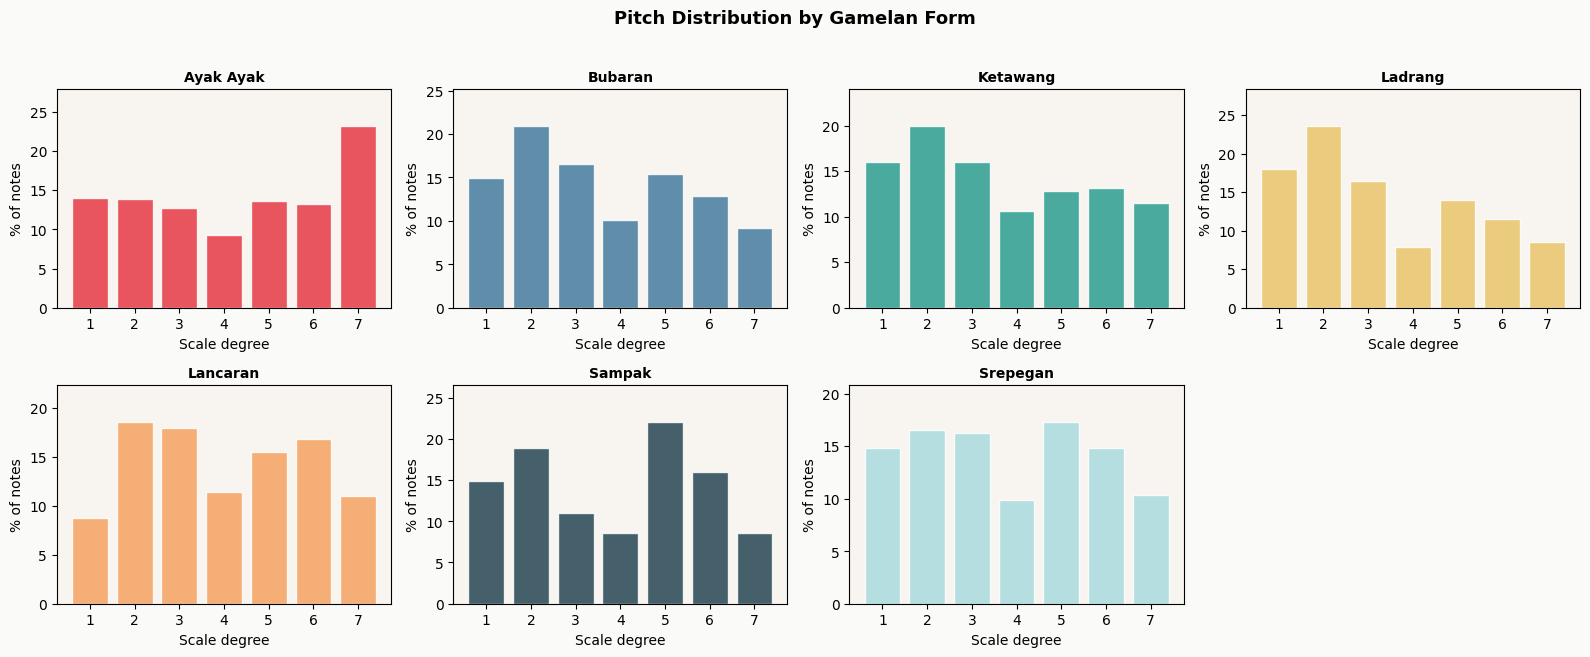

In [7]:
pitches_range = [1, 2, 3, 4, 5, 6, 7]
cols = min(4, len(genres))
rows = math.ceil(len(genres) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3.2))
axes = np.array(axes).flatten()

for i, genre in enumerate(genres):
    ax = axes[i]
    pd_g = genre_stats[genre]["pitch_dist"]
    tot = sum(pd_g.values()) or 1
    vals = [pd_g.get(p, 0) / tot * 100 for p in pitches_range]
    ax.bar([str(p) for p in pitches_range], vals, color=colors[genre], alpha=0.85, edgecolor="white")
    ax.set_title(genre, fontsize=10, fontweight="bold")
    ax.set_xlabel("Scale degree")
    ax.set_ylabel("% of notes")
    ax.set_ylim(0, max(vals) * 1.2 if vals else 10)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Pitch Distribution by Gamelan Form", fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

### 4.2 Register usage

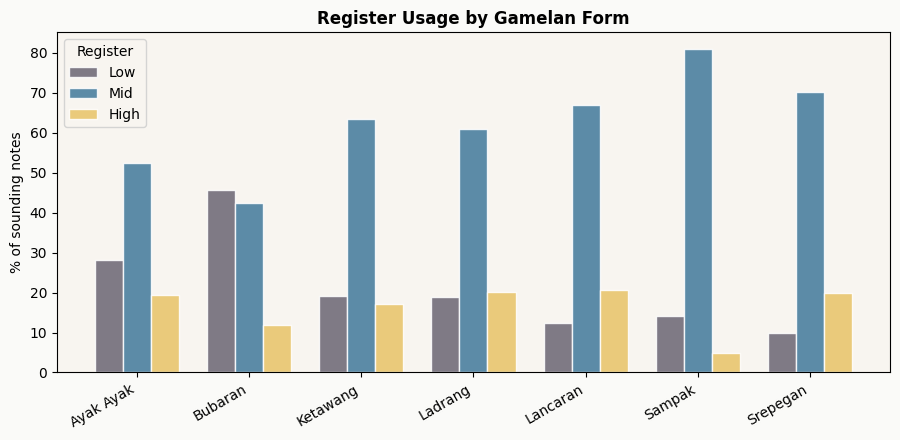

In [8]:
reg_labels = ["Low", "Mid", "High"]
reg_keys = [-1, 0, 1]
reg_colors = ["#6D6875", "#457B9D", "#E9C46A"]

fig, ax = plt.subplots(figsize=(max(8, len(genres) * 1.3), 4.5))
x = np.arange(len(genres))
width = 0.25

for k, (reg, lab, rc) in enumerate(zip(reg_keys, reg_labels, reg_colors)):
    vals = []
    for g in genres:
        rd = genre_stats[g]["register_dist"]
        tot = sum(rd.values()) or 1
        vals.append(rd.get(reg, 0) / tot * 100)
    ax.bar(x + k * width, vals, width, label=lab, color=rc, alpha=0.87, edgecolor="white")

ax.set_xticks(x + width)
ax.set_xticklabels(genres, rotation=30, ha="right")
ax.legend(title="Register")
ax.set_ylabel("% of sounding notes")
ax.set_title("Register Usage by Gamelan Form", fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()

### 4.3 Melodic intervals and gong cycle structure

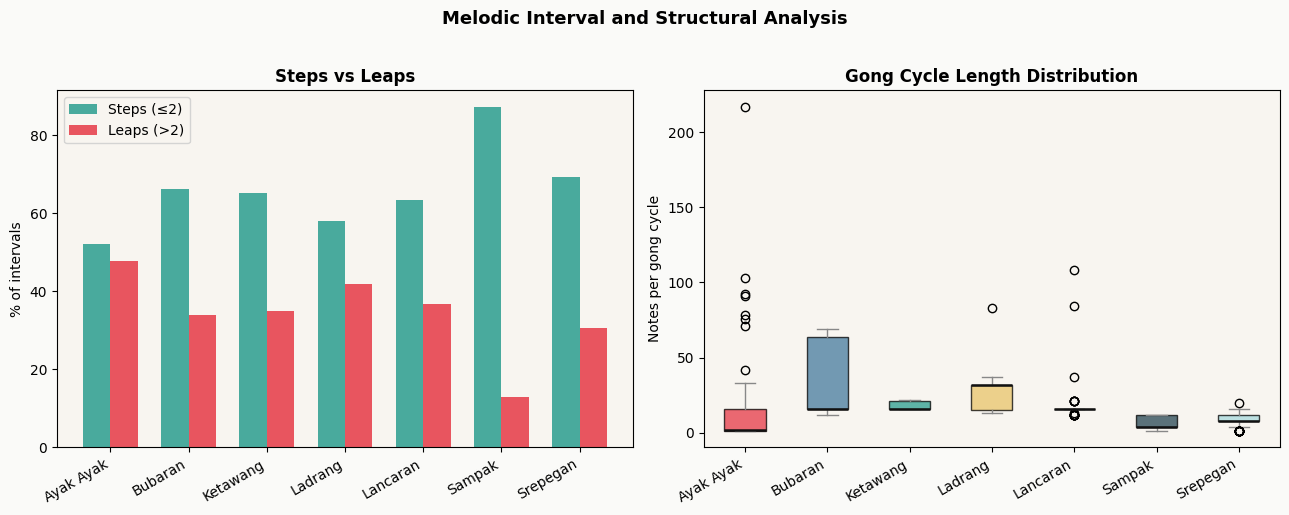

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

x = np.arange(len(genres))
w = 0.35
step_ratios = [genre_stats[g]["interval_stats"]["step_ratio"] * 100 for g in genres]
leap_ratios = [genre_stats[g]["interval_stats"]["leap_ratio"] * 100 for g in genres]
ax1.bar(x - w/2, step_ratios, w, label="Steps (\u22642)", color="#2A9D8F", alpha=0.85)
ax1.bar(x + w/2, leap_ratios, w, label="Leaps (>2)", color="#E63946", alpha=0.85)
ax1.set_xticks(x)
ax1.set_xticklabels(genres, rotation=30, ha="right")
ax1.legend()
ax1.set_ylabel("% of intervals")
ax1.set_title("Steps vs Leaps", fontweight="bold")

gong_data = [genre_stats[g]["gong_densities"] for g in genres if genre_stats[g]["gong_densities"]]
gong_genres = [g for g in genres if genre_stats[g]["gong_densities"]]
if gong_data:
    bp = ax2.boxplot(gong_data, patch_artist=True,
                     medianprops=dict(color="#111", linewidth=1.8),
                     whiskerprops=dict(color="#888"), capprops=dict(color="#888"))
    for patch, g in zip(bp["boxes"], gong_genres):
        patch.set_facecolor(colors[g])
        patch.set_alpha(0.75)
    ax2.set_xticklabels(gong_genres, rotation=30, ha="right")
    ax2.set_ylabel("Notes per gong cycle")
    ax2.set_title("Gong Cycle Length Distribution", fontweight="bold")

fig.suptitle("Melodic Interval and Structural Analysis", fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

### 4.4 Section occurrence heatmap

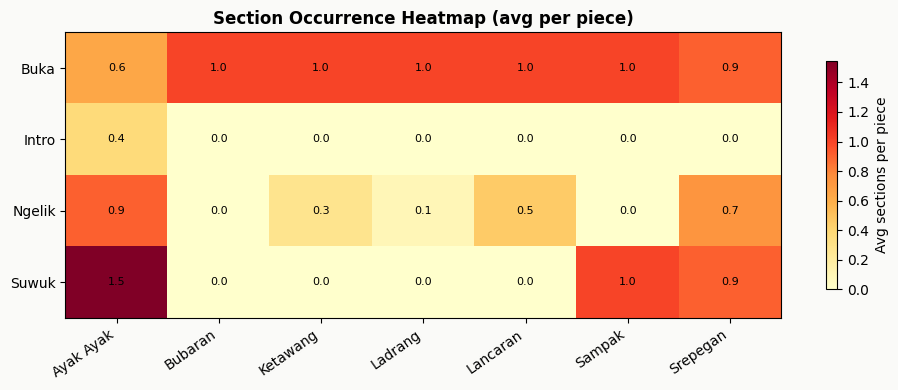

In [10]:
all_sec_types = sorted({s for g in genres for s in genre_stats[g]["section_counts"].keys()})

matrix = np.array([
    [genre_stats[g]["section_counts"].get(s, 0) / (genre_stats[g]["n_pieces"] or 1)
     for g in genres]
    for s in all_sec_types
], dtype=float)

fig, ax = plt.subplots(figsize=(max(9, len(genres) * 1.4), max(4, len(all_sec_types) * 0.7)))
im = ax.imshow(matrix, aspect="auto", cmap="YlOrRd", interpolation="nearest")
ax.set_xticks(range(len(genres)))
ax.set_xticklabels(genres, rotation=35, ha="right")
ax.set_yticks(range(len(all_sec_types)))
ax.set_yticklabels(all_sec_types)
for i in range(len(all_sec_types)):
    for j in range(len(genres)):
        ax.text(j, i, f"{matrix[i, j]:.1f}", ha="center", va="center",
                fontsize=8, color="black" if matrix[i, j] < 3 else "white")
plt.colorbar(im, ax=ax, label="Avg sections per piece", shrink=0.8)
ax.set_title("Section Occurrence Heatmap (avg per piece)", fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()

### 4.5 Radar overview

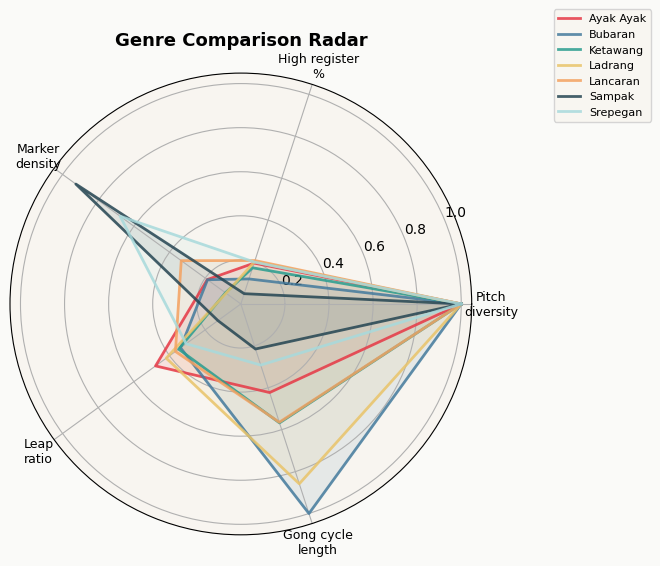

In [11]:
dimensions = ["Pitch\ndiversity", "High register\n%", "Marker\ndensity", "Leap\nratio", "Gong cycle\nlength"]

def extract_radar(g):
    s = genre_stats[g]
    pd_g = s["pitch_dist"]
    total = sum(pd_g.values()) or 1
    pitch_div = len([v for v in pd_g.values() if v / total > 0.05]) / 7
    hi_reg = s["register_dist"].get(1, 0) / (sum(s["register_dist"].values()) or 1)
    marker = min(s["marker_density"] / 2.0, 1.0)
    leap = s["interval_stats"]["leap_ratio"]
    gong_mean = np.mean(s["gong_densities"]) / 32 if s["gong_densities"] else 0
    return [pitch_div, hi_reg, marker, leap, min(gong_mean, 1.0)]

N_dims = len(dimensions)
angles = np.linspace(0, 2 * np.pi, N_dims, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
for genre in genres:
    vals = extract_radar(genre) + extract_radar(genre)[:1]
    ax.plot(angles, vals, color=colors[genre], linewidth=2, alpha=0.85, label=genre)
    ax.fill(angles, vals, color=colors[genre], alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(dimensions, fontsize=9)
ax.set_title("Genre Comparison Radar", fontsize=13, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.4, 1.15), fontsize=8)
fig.tight_layout()
plt.show()

### 4.6 Feature correlation matrix

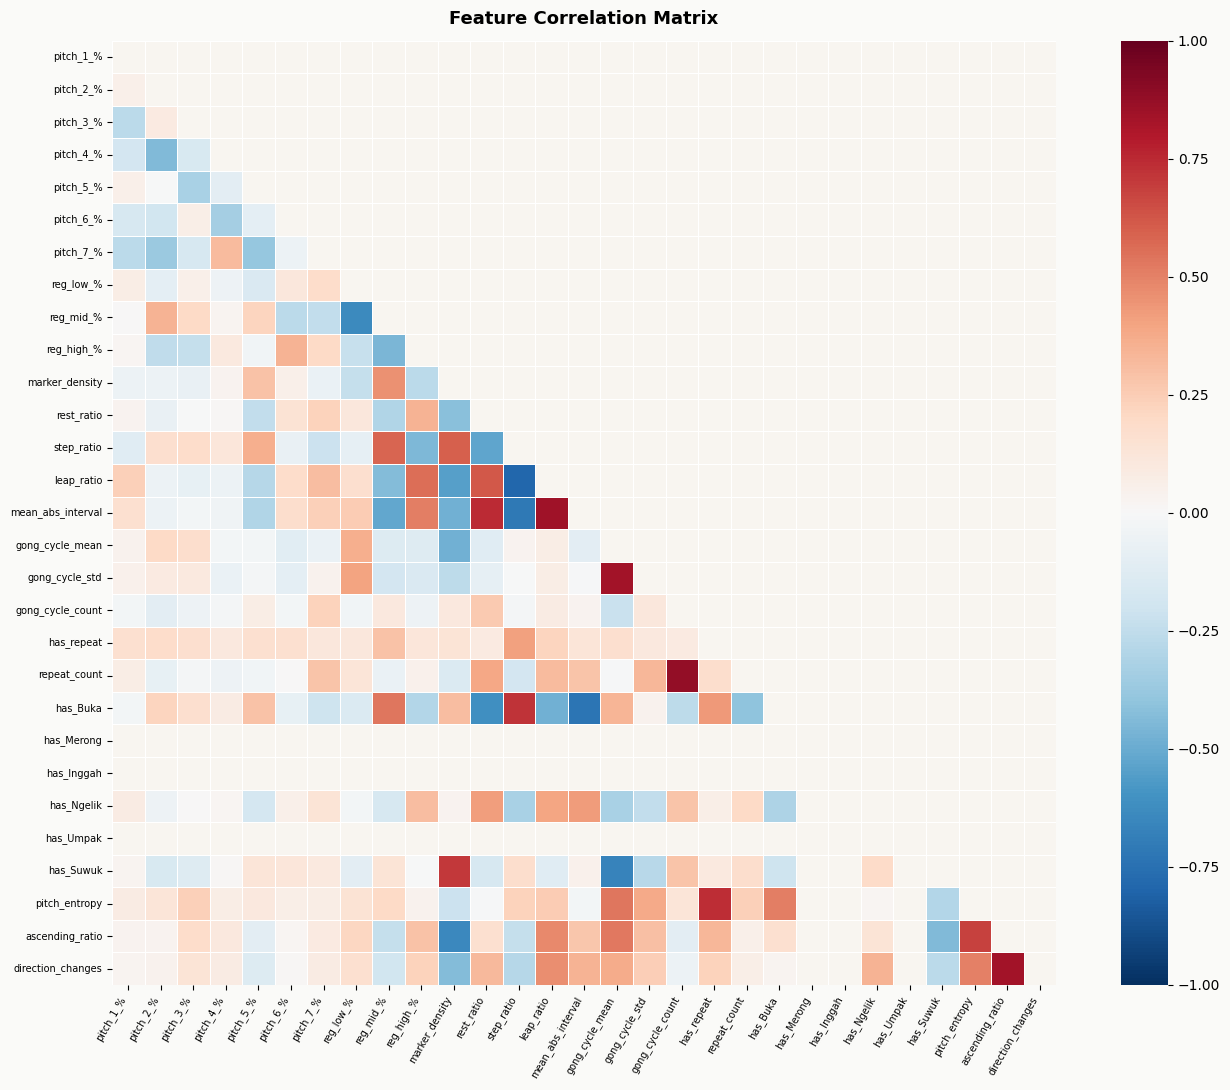

In [12]:
fig, ax = plt.subplots(figsize=(14, 11))
corr = df_features[FEATURE_NAMES].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0, annot=False,
            square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1,
            xticklabels=FEATURE_NAMES, yticklabels=FEATURE_NAMES)
ax.set_title("Feature Correlation Matrix", fontsize=13, fontweight="bold", pad=12)
plt.xticks(rotation=60, ha="right", fontsize=7)
plt.yticks(fontsize=7)
fig.tight_layout()
plt.show()

---
## 5. Evaluation Protocol <a id='5-protocol'></a>

All three datasets are evaluated under the **same protocol**: Leave-One-Out / Leave-One-Group-Out CV with **35 folds** (one per original piece). For augmented datasets, LOGOCV holds out an original **and all its transpositions**; for the original 35-piece dataset, this reduces to standard LOOCV.

- **Classical models (DT, RF, SVM, KNN):** LOGOCV via `cross_val_predict`. SVM and KNN use `Pipeline(StandardScaler, model)` so the scaler is fitted within each fold.
- **Neural models (MLP, 1D CNN):** Custom LOGOCV loop with per-fold scaling (MLP) or raw-sequence slicing (CNN), class-weighted loss (augmented only), and 300 epochs per fold.
- **Hold-out split** is additionally used for neural-model training curves and embedding visualisation only — it does **not** contribute to the primary metrics.

This unified protocol makes accuracy and macro-F1 directly comparable across all three datasets and all six models.

In [13]:
# Hold-out split (for neural model training curves / visualisation only)
train_records, test_records = stratified_split(records)
X_train, y_train, _ = to_arrays(train_records, le)
X_test, y_test, _ = to_arrays(test_records, le)

scaler_split = StandardScaler().fit(X_train)
X_train_s = scaler_split.transform(X_train).astype(np.float32)
X_test_s = scaler_split.transform(X_test).astype(np.float32)

cw_train = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)

print("Hold-out split (used for visualisation only — primary metric is LOGOCV)")
print(f"  {len(train_records)} train / {len(test_records)} test")
print(f"  Class weights (train): {dict(zip(le.classes_[np.unique(y_train)], cw_train.round(3)))}")

  Ayak Ayak: 5 originals → 5 train pieces / 6 test pieces
  Bubaran: 5 originals → 4 train pieces / 7 test pieces
  Ketawang: 5 originals → 4 train pieces / 7 test pieces
  Ladrang: 5 originals → 5 train pieces / 6 test pieces
  Lancaran: 5 originals → 6 train pieces / 5 test pieces
  Sampak: 5 originals → 4 train pieces / 7 test pieces
  Srepegan: 5 originals → 4 train pieces / 7 test pieces
Hold-out split (used for visualisation only — primary metric is LOGOCV)
  32 train / 45 test
  Class weights (train): {np.str_('Ayak Ayak'): np.float64(0.914), np.str_('Bubaran'): np.float64(1.143), np.str_('Ketawang'): np.float64(1.143), np.str_('Ladrang'): np.float64(0.914), np.str_('Lancaran'): np.float64(0.762), np.str_('Sampak'): np.float64(1.143), np.str_('Srepegan'): np.float64(1.143)}


---
## 6. Model 1 — Decision Tree <a id='6-dt'></a>

A `DecisionTreeClassifier` with a depth sweep to find the best generalising depth. This model provides full explainability through its decision rules.

In [14]:
from sklearn.model_selection import LeaveOneGroupOut

groups, unique_originals = get_logo_groups(records)
logo = LeaveOneGroupOut()

print(f"Unique original pieces (groups): {len(unique_originals)}")
print(f"Samples per group (min/max): {np.bincount(groups).min()} / {np.bincount(groups).max()}")
print(f"Number of LOGO folds: {logo.get_n_splits(X_feat, y, groups)}")

Unique original pieces (groups): 35
Samples per group (min/max): 1 / 7
Number of LOGO folds: 35


In [15]:
best_loo_acc_dt = 0
best_depth_dt = 1

for depth in range(1, 16):
    dt = DecisionTreeClassifier(max_depth=depth, class_weight='balanced', random_state=42)
    y_pred_loo = cross_val_predict(dt, X_feat, y, cv=logo, groups=groups)
    acc = accuracy_score(y, y_pred_loo)
    if acc > best_loo_acc_dt:
        best_loo_acc_dt = acc
        best_depth_dt = depth

dt_final = DecisionTreeClassifier(max_depth=best_depth_dt, class_weight='balanced', random_state=42)
y_pred_dt_loo = cross_val_predict(dt_final, X_feat, y, cv=logo, groups=groups)
dt_loo_acc = accuracy_score(y, y_pred_dt_loo)
dt_loo_f1 = f1_score(y, y_pred_dt_loo, average="macro")

print(f"Decision Tree — LOGOCV Results")
print(f"  Best depth: {best_depth_dt}")
print(f"  Accuracy:   {dt_loo_acc:.1%}")
print(f"  Macro F1:   {dt_loo_f1:.3f}")
print()
print(classification_report(y, y_pred_dt_loo, target_names=class_names, zero_division=0))

Decision Tree — LOGOCV Results
  Best depth: 5
  Accuracy:   76.6%
  Macro F1:   0.751

              precision    recall  f1-score   support

   Ayak Ayak       0.67      0.91      0.77        11
     Bubaran       0.50      0.18      0.27        11
    Ketawang       1.00      0.91      0.95        11
     Ladrang       1.00      1.00      1.00        11
    Lancaran       0.36      0.45      0.40        11
      Sampak       0.92      1.00      0.96        11
    Srepegan       0.91      0.91      0.91        11

    accuracy                           0.77        77
   macro avg       0.76      0.77      0.75        77
weighted avg       0.76      0.77      0.75        77



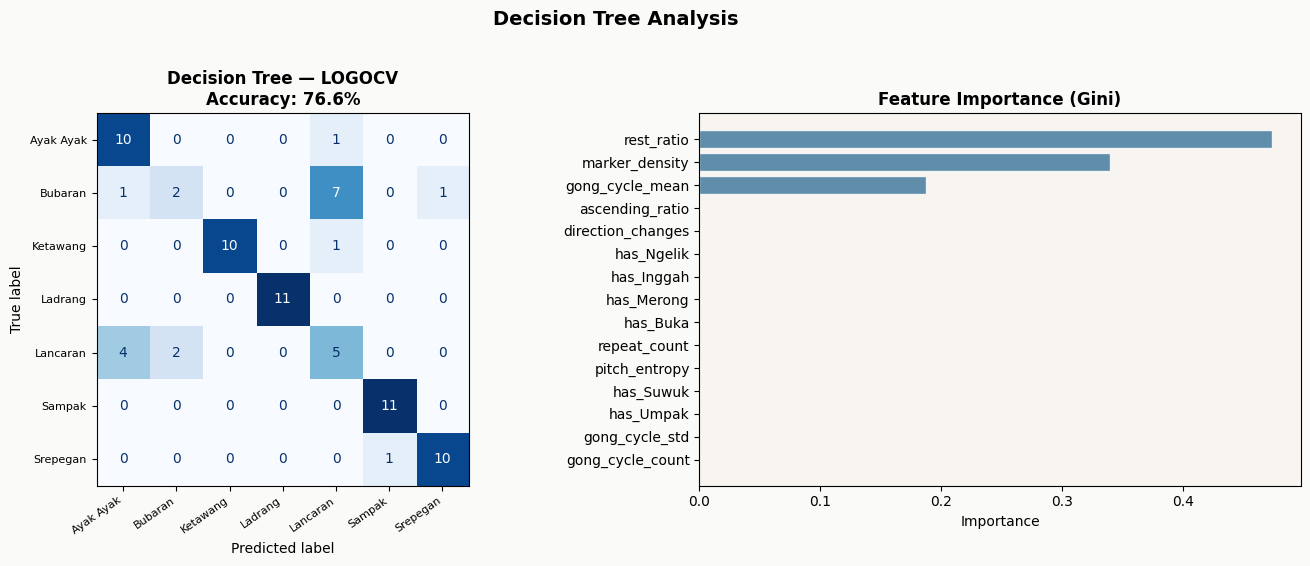

In [16]:
dt_full = DecisionTreeClassifier(max_depth=best_depth_dt, class_weight='balanced', random_state=42)
dt_full.fit(X_feat, y)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

cm_loo = confusion_matrix(y, y_pred_dt_loo)
ConfusionMatrixDisplay(cm_loo, display_labels=class_names).plot(ax=ax1, cmap="Blues", colorbar=False)
ax1.set_title(f"Decision Tree — LOGOCV\nAccuracy: {dt_loo_acc:.1%}", fontweight="bold")
ax1.set_xticklabels(class_names, rotation=35, ha="right", fontsize=8)
ax1.set_yticklabels(class_names, fontsize=8)

imp = dt_full.feature_importances_
top_k = min(15, N_FEATURES)
idx = np.argsort(imp)[::-1][:top_k]
ax2.barh([FEATURE_NAMES[i] for i in idx][::-1], [imp[i] for i in idx][::-1],
         color="#457B9D", alpha=0.85, edgecolor="white")
ax2.set_title("Feature Importance (Gini)", fontweight="bold")
ax2.set_xlabel("Importance")

fig.suptitle("Decision Tree Analysis", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

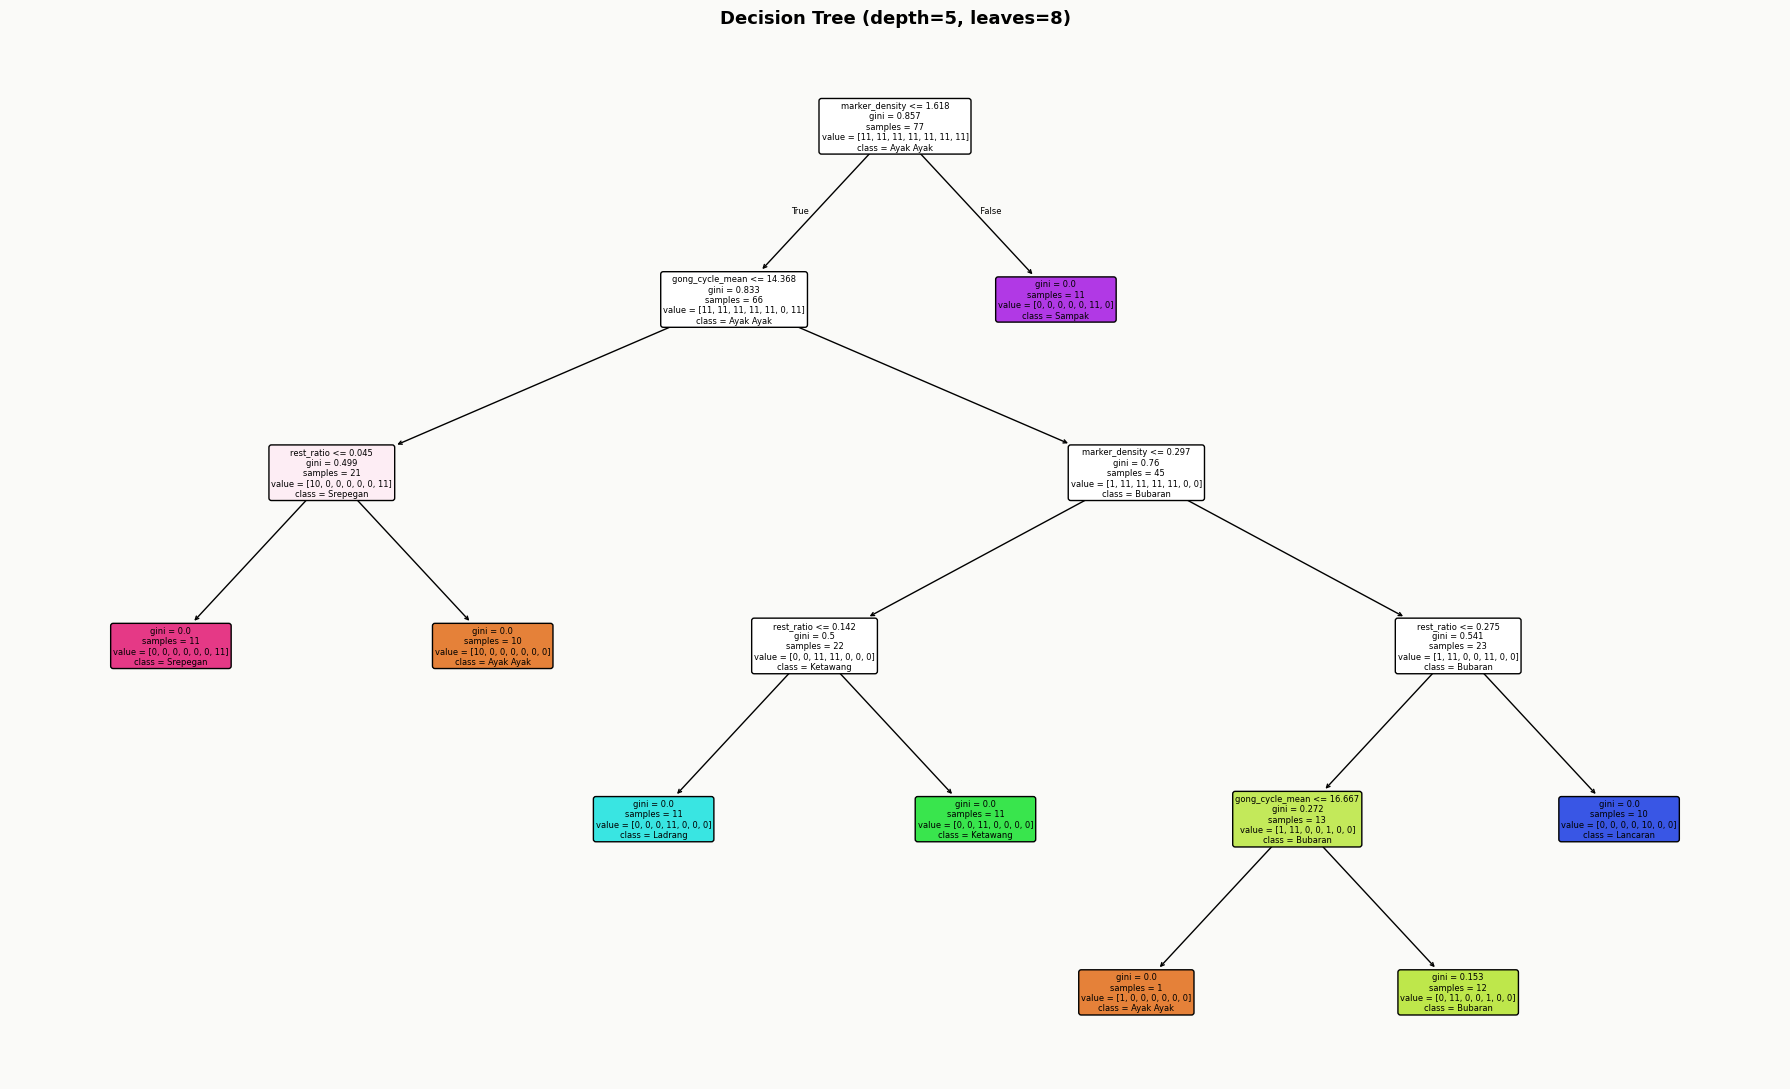


── Decision Rules ──
|--- marker_density <= 1.62
|   |--- gong_cycle_mean <= 14.37
|   |   |--- rest_ratio <= 0.04
|   |   |   |--- class: 6
|   |   |--- rest_ratio >  0.04
|   |   |   |--- class: 0
|   |--- gong_cycle_mean >  14.37
|   |   |--- marker_density <= 0.30
|   |   |   |--- rest_ratio <= 0.14
|   |   |   |   |--- class: 3
|   |   |   |--- rest_ratio >  0.14
|   |   |   |   |--- class: 2
|   |   |--- marker_density >  0.30
|   |   |   |--- rest_ratio <= 0.27
|   |   |   |   |--- gong_cycle_mean <= 16.67
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- gong_cycle_mean >  16.67
|   |   |   |   |   |--- class: 1
|   |   |   |--- rest_ratio >  0.27
|   |   |   |   |--- class: 4
|--- marker_density >  1.62
|   |--- class: 5



In [17]:
n_leaves = dt_full.get_n_leaves()
depth = dt_full.get_depth()
fig, ax = plt.subplots(figsize=(max(18, n_leaves * 2.2), max(7, depth * 2.2)))
plot_tree(dt_full, ax=ax, feature_names=FEATURE_NAMES, class_names=class_names,
          filled=True, rounded=True, impurity=True, proportion=False,
          fontsize=max(5, min(9, 50 // max(n_leaves, 1))))
ax.set_title(f"Decision Tree (depth={depth}, leaves={n_leaves})", fontsize=13, fontweight="bold", pad=12)
fig.tight_layout()
plt.show()

print("\n── Decision Rules ──")
print(export_text(dt_full, feature_names=list(FEATURE_NAMES), max_depth=best_depth_dt))

---
## 7. Model 2 — Random Forest <a id='7-rf'></a>

An ensemble of decision trees to reduce variance and improve generalisation.

In [18]:
best_loo_acc_rf = 0
best_n_estimators = 50

for n_est in [50, 100, 200, 300]:
    rf = RandomForestClassifier(n_estimators=n_est, max_depth=best_depth_dt + 2,
                                class_weight='balanced', random_state=42)
    y_pred_loo_rf = cross_val_predict(rf, X_feat, y, cv=logo, groups=groups)
    acc = accuracy_score(y, y_pred_loo_rf)
    if acc > best_loo_acc_rf:
        best_loo_acc_rf = acc
        best_n_estimators = n_est

rf_final = RandomForestClassifier(n_estimators=best_n_estimators, max_depth=best_depth_dt + 2,
                                  class_weight='balanced', random_state=42)
y_pred_rf_loo = cross_val_predict(rf_final, X_feat, y, cv=logo, groups=groups)
rf_loo_acc = accuracy_score(y, y_pred_rf_loo)
rf_loo_f1 = f1_score(y, y_pred_rf_loo, average="macro")

print(f"Random Forest — LOGOCV Results")
print(f"  n_estimators: {best_n_estimators}, max_depth: {best_depth_dt + 2}")
print(f"  Accuracy:     {rf_loo_acc:.1%}")
print(f"  Macro F1:     {rf_loo_f1:.3f}")
print()
print(classification_report(y, y_pred_rf_loo, target_names=class_names, zero_division=0))

Random Forest — LOGOCV Results
  n_estimators: 200, max_depth: 7
  Accuracy:     74.0%
  Macro F1:     0.720

              precision    recall  f1-score   support

   Ayak Ayak       1.00      0.45      0.62        11
     Bubaran       0.75      0.55      0.63        11
    Ketawang       0.62      0.91      0.74        11
     Ladrang       0.73      1.00      0.85        11
    Lancaran       0.80      0.36      0.50        11
      Sampak       0.92      1.00      0.96        11
    Srepegan       0.62      0.91      0.74        11

    accuracy                           0.74        77
   macro avg       0.78      0.74      0.72        77
weighted avg       0.78      0.74      0.72        77



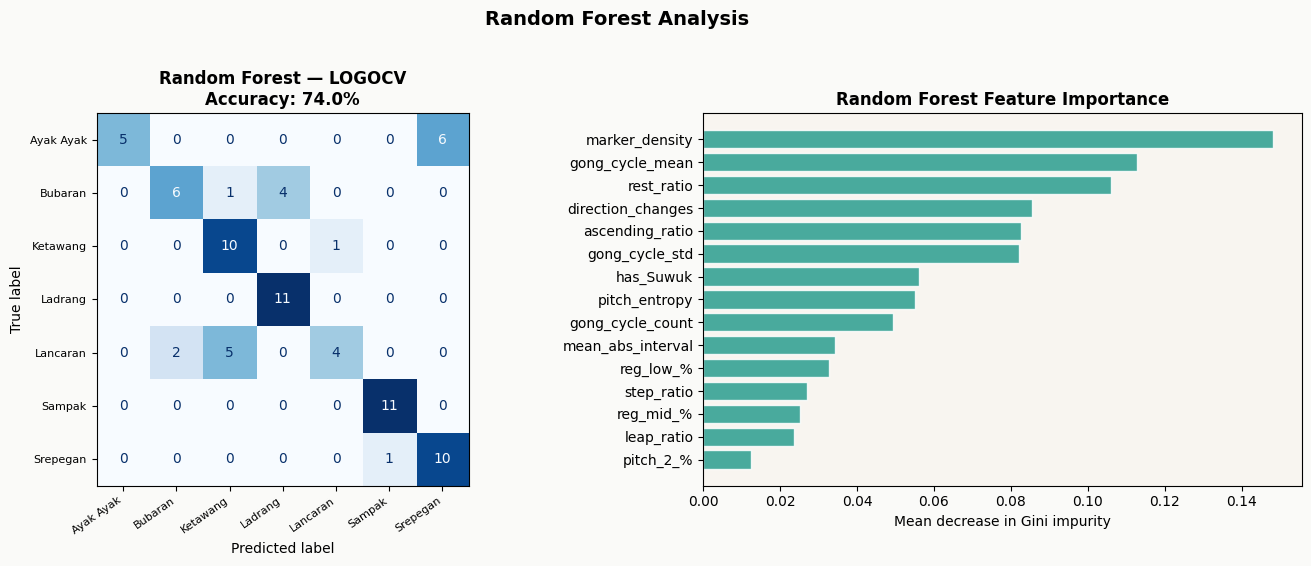

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

cm_rf = confusion_matrix(y, y_pred_rf_loo)
ConfusionMatrixDisplay(cm_rf, display_labels=class_names).plot(ax=ax1, cmap="Blues", colorbar=False)
ax1.set_title(f"Random Forest — LOGOCV\nAccuracy: {rf_loo_acc:.1%}", fontweight="bold")
ax1.set_xticklabels(class_names, rotation=35, ha="right", fontsize=8)
ax1.set_yticklabels(class_names, fontsize=8)

rf_full = RandomForestClassifier(n_estimators=best_n_estimators, max_depth=best_depth_dt + 2,
                                  class_weight='balanced', random_state=42)
rf_full.fit(X_feat, y)
imp_rf = rf_full.feature_importances_
idx_rf = np.argsort(imp_rf)[::-1][:top_k]
ax2.barh([FEATURE_NAMES[i] for i in idx_rf][::-1], [imp_rf[i] for i in idx_rf][::-1],
         color="#2A9D8F", alpha=0.85, edgecolor="white")
ax2.set_title("Random Forest Feature Importance", fontweight="bold")
ax2.set_xlabel("Mean decrease in Gini impurity")

fig.suptitle("Random Forest Analysis", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

---
## 8. Model 3 — Support Vector Machine <a id='8-svm'></a>

SVM with RBF kernel, operating on standardised features.

In [20]:
best_loo_acc_svm = 0
best_C = 1.0

for C in [0.1, 1.0, 10.0, 100.0]:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(C=C, kernel="rbf", gamma="scale", class_weight='balanced', random_state=42)),
    ])
    y_pred_loo_svm = cross_val_predict(pipe, X_feat, y, cv=logo, groups=groups)
    acc = accuracy_score(y, y_pred_loo_svm)
    if acc > best_loo_acc_svm:
        best_loo_acc_svm = acc
        best_C = C

svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(C=best_C, kernel="rbf", gamma="scale", class_weight='balanced', random_state=42)),
])
y_pred_svm_loo = cross_val_predict(svm_pipe, X_feat, y, cv=logo, groups=groups)
svm_loo_acc = accuracy_score(y, y_pred_svm_loo)
svm_loo_f1 = f1_score(y, y_pred_svm_loo, average="macro")

print(f"SVM (RBF) — LOGOCV Results  (Pipeline: StandardScaler → SVC, class_weight='balanced')")
print(f"  C:        {best_C}")
print(f"  Accuracy: {svm_loo_acc:.1%}")
print(f"  Macro F1: {svm_loo_f1:.3f}")
print()
print(classification_report(y, y_pred_svm_loo, target_names=class_names, zero_division=0))

SVM (RBF) — LOGOCV Results  (Pipeline: StandardScaler → SVC, class_weight='balanced')
  C:        10.0
  Accuracy: 44.2%
  Macro F1: 0.454

              precision    recall  f1-score   support

   Ayak Ayak       0.33      0.45      0.38        11
     Bubaran       0.42      0.45      0.43        11
    Ketawang       0.40      0.55      0.46        11
     Ladrang       0.15      0.18      0.17        11
    Lancaran       1.00      0.27      0.43        11
      Sampak       1.00      0.64      0.78        11
    Srepegan       0.50      0.55      0.52        11

    accuracy                           0.44        77
   macro avg       0.54      0.44      0.45        77
weighted avg       0.54      0.44      0.45        77



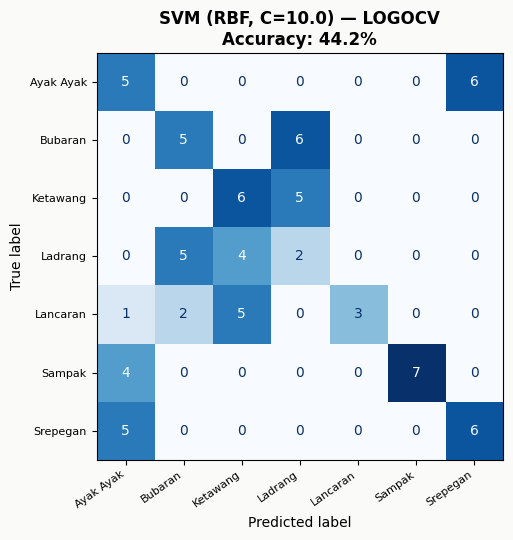

In [21]:
fig, ax = plt.subplots(figsize=(7, 5.5))
cm_svm = confusion_matrix(y, y_pred_svm_loo)
ConfusionMatrixDisplay(cm_svm, display_labels=class_names).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"SVM (RBF, C={best_C}) — LOGOCV\nAccuracy: {svm_loo_acc:.1%}", fontweight="bold")
ax.set_xticklabels(class_names, rotation=35, ha="right", fontsize=8)
ax.set_yticklabels(class_names, fontsize=8)
fig.tight_layout()
plt.show()

---
## 9. Model 4 — k-Nearest Neighbors <a id='9-knn'></a>

In [22]:
best_loo_acc_knn = 0
best_k = 3

for k in [1, 3, 5, 7]:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=k, weights='distance')),
    ])
    y_pred_loo_knn = cross_val_predict(pipe, X_feat, y, cv=logo, groups=groups)
    acc = accuracy_score(y, y_pred_loo_knn)
    if acc > best_loo_acc_knn:
        best_loo_acc_knn = acc
        best_k = k

knn_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=best_k, weights='distance')),
])
y_pred_knn_loo = cross_val_predict(knn_pipe, X_feat, y, cv=logo, groups=groups)
knn_loo_acc = accuracy_score(y, y_pred_knn_loo)
knn_loo_f1 = f1_score(y, y_pred_knn_loo, average="macro")

print(f"KNN — LOGOCV Results  (Pipeline: StandardScaler → KNN, weights='distance')")
print(f"  k:        {best_k}")
print(f"  Accuracy: {knn_loo_acc:.1%}")
print(f"  Macro F1: {knn_loo_f1:.3f}")
print()
print(classification_report(y, y_pred_knn_loo, target_names=class_names, zero_division=0))

KNN — LOGOCV Results  (Pipeline: StandardScaler → KNN, weights='distance')
  k:        1
  Accuracy: 46.8%
  Macro F1: 0.468

              precision    recall  f1-score   support

   Ayak Ayak       0.56      0.45      0.50        11
     Bubaran       0.64      0.64      0.64        11
    Ketawang       0.24      0.36      0.29        11
     Ladrang       0.08      0.09      0.08        11
    Lancaran       0.50      0.18      0.27        11
      Sampak       0.92      1.00      0.96        11
    Srepegan       0.55      0.55      0.55        11

    accuracy                           0.47        77
   macro avg       0.50      0.47      0.47        77
weighted avg       0.50      0.47      0.47        77



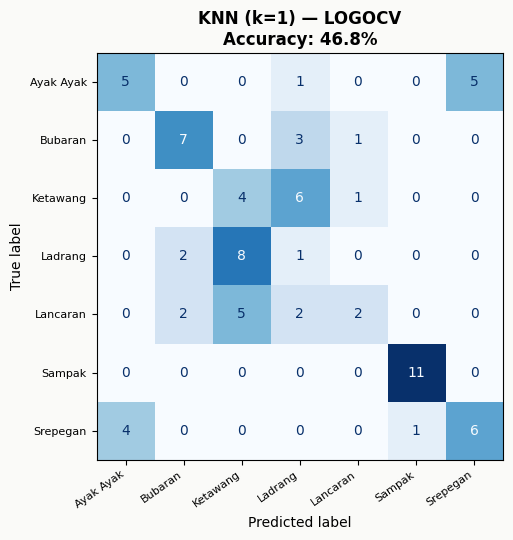

In [23]:
fig, ax = plt.subplots(figsize=(7, 5.5))
cm_knn = confusion_matrix(y, y_pred_knn_loo)
ConfusionMatrixDisplay(cm_knn, display_labels=class_names).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"KNN (k={best_k}) — LOGOCV\nAccuracy: {knn_loo_acc:.1%}", fontweight="bold")
ax.set_xticklabels(class_names, rotation=35, ha="right", fontsize=8)
ax.set_yticklabels(class_names, fontsize=8)
fig.tight_layout()
plt.show()

---
## 10. Model 5 — MLP (Neural Network) <a id='10-mlp'></a>

A two-hidden-layer PyTorch MLP operating on z-scored features.

**Architecture:** Input(29) → Linear(64) → BN → ReLU → Dropout → Linear(32) → BN → ReLU → Dropout → Linear(7)

Model and training loop imported from `src.gamelan_mlp`.

In [24]:
print("Training MLP (src.gamelan_mlp, class-weighted loss)...\n")
mlp_model, mlp_history = train_mlp(
    X_train_s, y_train,
    X_test_s, y_test,
    n_classes,
    class_weights=cw_train,
)

mlp_model.eval()
with torch.no_grad():
    mlp_proba = torch.softmax(mlp_model(torch.tensor(X_test_s)), dim=1).numpy()
    mlp_pred = mlp_proba.argmax(axis=1)

mlp_holdout_acc = accuracy_score(y_test, mlp_pred)
mlp_holdout_f1 = f1_score(y_test, mlp_pred, average="macro", zero_division=0)
mlp_best_test_acc = max(mlp_history["test_acc"])

test_ids = sorted(set(y_test))
test_names = [le.classes_[i] for i in test_ids]

print(f"\nMLP — Hold-out Results")
print(f"  Final test accuracy: {mlp_holdout_acc:.1%}")
print(f"  Best test accuracy:  {mlp_best_test_acc:.1%}")
print(f"  Macro F1:            {mlp_holdout_f1:.3f}")
print()
print(classification_report(y_test, mlp_pred, target_names=test_names, zero_division=0))

Training MLP (src.gamelan_mlp, class-weighted loss)...

  epoch    1  train loss 1.9066  acc 15.6%  │  test loss 1.9690  acc 11.1%
  epoch  100  train loss 0.0183  acc 100.0%  │  test loss 1.9286  acc 55.6%
  epoch  200  train loss 0.0040  acc 100.0%  │  test loss 2.7332  acc 48.9%
  epoch  300  train loss 0.0025  acc 100.0%  │  test loss 3.1655  acc 46.7%
  epoch  400  train loss 0.0010  acc 100.0%  │  test loss 3.6984  acc 48.9%
  epoch  500  train loss 0.0009  acc 100.0%  │  test loss 3.7566  acc 48.9%
  epoch  600  train loss 0.0008  acc 100.0%  │  test loss 3.8060  acc 53.3%

MLP — Hold-out Results
  Final test accuracy: 53.3%
  Best test accuracy:  64.4%
  Macro F1:            0.511

              precision    recall  f1-score   support

   Ayak Ayak       0.67      0.33      0.44         6
     Bubaran       0.39      1.00      0.56         7
    Ketawang       0.33      0.14      0.20         7
     Ladrang       0.17      0.17      0.17         6
    Lancaran       1.00      0

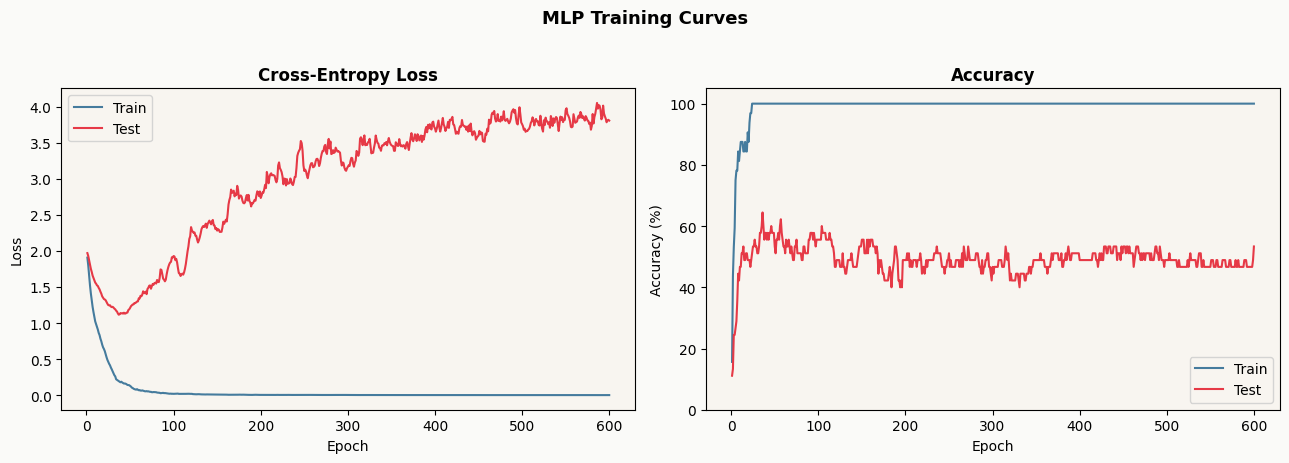

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
epochs = range(1, len(mlp_history["train_loss"]) + 1)

ax1.plot(epochs, mlp_history["train_loss"], color="#457B9D", lw=1.5, label="Train")
ax1.plot(epochs, mlp_history["test_loss"], color="#E63946", lw=1.5, label="Test")
ax1.legend(); ax1.set_title("Cross-Entropy Loss", fontweight="bold")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")

ax2.plot(epochs, [a * 100 for a in mlp_history["train_acc"]], color="#457B9D", lw=1.5, label="Train")
ax2.plot(epochs, [a * 100 for a in mlp_history["test_acc"]], color="#E63946", lw=1.5, label="Test")
ax2.set_ylim(0, 105); ax2.legend()
ax2.set_title("Accuracy", fontweight="bold")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy (%)")

fig.suptitle("MLP Training Curves", fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

In [26]:
print("MLP — Leave-One-Group-Out CV (35 folds × 300 epochs)...\n")

logo_mlp = LeaveOneGroupOut()
n_folds_mlp = logo_mlp.get_n_splits(X_feat, y, groups)
y_pred_mlp_logo = np.zeros(len(y), dtype=int)

for fold, (tr_idx, te_idx) in enumerate(logo_mlp.split(X_feat, y, groups)):
    X_tr_f, X_te_f = X_feat[tr_idx], X_feat[te_idx]
    y_tr_f, y_te_f = y[tr_idx], y[te_idx]

    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr_f).astype(np.float32)
    X_te_s_f = sc.transform(X_te_f).astype(np.float32)

    cw = compute_class_weight('balanced', classes=np.unique(y_tr_f), y=y_tr_f)
    model_f, _ = train_mlp(X_tr_s, y_tr_f, X_te_s_f, y_te_f, n_classes,
                            n_epochs=300, class_weights=cw, verbose=False)

    model_f.eval()
    with torch.no_grad():
        y_pred_mlp_logo[te_idx] = model_f(torch.tensor(X_te_s_f)).argmax(1).numpy()

    if (fold + 1) % 10 == 0 or fold == 0:
        print(f"  Fold {fold+1:2d}/{n_folds_mlp}")

mlp_logo_acc = accuracy_score(y, y_pred_mlp_logo)
mlp_logo_f1 = f1_score(y, y_pred_mlp_logo, average="macro")

print(f"\nMLP — LOGOCV Results (balanced dataset)")
print(f"  Accuracy: {mlp_logo_acc:.1%}")
print(f"  Macro F1: {mlp_logo_f1:.3f}")
print()
print(classification_report(y, y_pred_mlp_logo, target_names=class_names, zero_division=0))

MLP — Leave-One-Group-Out CV (35 folds × 300 epochs)...

  Fold  1/35
  Fold 10/35
  Fold 20/35
  Fold 30/35

MLP — LOGOCV Results (balanced dataset)
  Accuracy: 66.2%
  Macro F1: 0.660

              precision    recall  f1-score   support

   Ayak Ayak       1.00      0.45      0.62        11
     Bubaran       0.69      0.82      0.75        11
    Ketawang       0.44      0.64      0.52        11
     Ladrang       0.36      0.36      0.36        11
    Lancaran       1.00      0.45      0.62        11
      Sampak       1.00      1.00      1.00        11
    Srepegan       0.62      0.91      0.74        11

    accuracy                           0.66        77
   macro avg       0.73      0.66      0.66        77
weighted avg       0.73      0.66      0.66        77



---
## 11. Model 6 — 1D CNN <a id='11-cnn'></a>

Operates on **raw note sequences** — no feature engineering. Each note is encoded as a 7-dim vector (pitch, octave, kenong, kethuk, gong, kempyang, is_rest).

Model and training loop imported from `src.gamelan_cnn`. Sequence loading uses `src.data.load_corpus_sequences()`.

In [27]:
print("Loading corpus (raw sequences for CNN)...\n")
seq_records = load_corpus_sequences(DATASET_ROOT)

seq_lengths = [r["seq_len"] for r in seq_records]
pad_len = int(np.percentile([l for l in seq_lengths if l > 0], 95))
print(f"\nSequence lengths — min: {min(seq_lengths)}, max: {max(seq_lengths)}, "
      f"mean: {np.mean(seq_lengths):.0f}, p95 (pad_len): {pad_len}")

seq_train, seq_test = stratified_split(seq_records)
X_seq_train, y_seq_train, le_seq = to_tensors(seq_train, pad_len)
X_seq_test, y_seq_test, _ = to_tensors(seq_test, pad_len, le_seq)

print(f"\nCNN input shape: {tuple(X_seq_train.shape)} (N, channels={N_DIMS}, time={pad_len})")
print(f"Train: {len(seq_train)} / Test: {len(seq_test)}")

Loading corpus (raw sequences for CNN)...

  ✅  Ayak Ayak / Ayak Ayak Manyura Slendro Manyura  (94 events)
  ✅  Ayak Ayak / Ayak Ayak Manyura Slendro Manyura shift+1  (94 events)
  ✅  Ayak Ayak / Ayak Ayak Nem Slendro Nem  (89 events)
  ✅  Ayak Ayak / Ayak Ayak Nem Slendro Nem shift+1  (89 events)
  ✅  Ayak Ayak / Ayak Ayak Nem Slendro Nem shift+2  (89 events)
  ✅  Ayak Ayak / Ayak Ayak Nem Slendro Nem shift+3  (89 events)
  ✅  Ayak Ayak / Ayak Ayak Nem Slendro Nem shift+4  (89 events)
  ✅  Ayak Ayak / Ayak Ayak Nem Slendro Nem shift-1  (89 events)
  ✅  Ayak Ayak / Ayak Ayak Pamungkas Slendro Manyura  (3410 events)
  ✅  Ayak Ayak / Ayak Ayak Sanga Slendro Sanga  (196 events)
  ✅  Ayak Ayak / Ayak Ayak Umbul Donga Slendro Manyura  (140 events)
  ✅  Bubaran / Bubaran Arum Arum Pelog Barang  (80 events)
  ✅  Bubaran / Bubaran Arum Arum Pelog Barang shift+1  (80 events)
  ✅  Bubaran / Bubaran Arum Arum Pelog Barang shift+2  (80 events)
  ✅  Bubaran / Bubaran Arum Arum Pelog Barang shift+3 

In [28]:
cw_seq = compute_class_weight('balanced', classes=np.unique(y_seq_train.numpy()), y=y_seq_train.numpy())
print("Training 1D-CNN (src.gamelan_cnn, class-weighted loss)...\n")
cnn_model, cnn_history = train_cnn(X_seq_train, y_seq_train, X_seq_test, y_seq_test, n_classes,
                                   class_weights=cw_seq)

cnn_model.eval()
with torch.no_grad():
    cnn_proba = torch.softmax(cnn_model(X_seq_test), dim=1).numpy()
    cnn_pred = cnn_proba.argmax(axis=1)

y_seq_test_np = y_seq_test.numpy()
cnn_holdout_acc = accuracy_score(y_seq_test_np, cnn_pred)
cnn_holdout_f1 = f1_score(y_seq_test_np, cnn_pred, average="macro", zero_division=0)
cnn_best_test_acc = max(cnn_history["test_acc"])

cnn_test_ids = sorted(set(y_seq_test_np))
cnn_test_names = [le_seq.classes_[i] for i in cnn_test_ids]

print(f"\n1D-CNN — Hold-out Results")
print(f"  Final test accuracy: {cnn_holdout_acc:.1%}")
print(f"  Best test accuracy:  {cnn_best_test_acc:.1%}")
print(f"  Macro F1:            {cnn_holdout_f1:.3f}")
print()
print(classification_report(y_seq_test_np, cnn_pred, target_names=cnn_test_names, zero_division=0))

Training 1D-CNN (src.gamelan_cnn, class-weighted loss)...

  epoch    1  train loss 1.9374  acc 28.1%  │  test loss 1.9523  acc 11.1%
  epoch  100  train loss 0.0044  acc 100.0%  │  test loss 0.2224  acc 95.6%
  epoch  200  train loss 0.0027  acc 100.0%  │  test loss 0.2794  acc 93.3%
  epoch  300  train loss 0.0008  acc 100.0%  │  test loss 0.4183  acc 88.9%
  epoch  400  train loss 0.0006  acc 100.0%  │  test loss 0.2824  acc 93.3%
  epoch  500  train loss 0.0004  acc 100.0%  │  test loss 0.2481  acc 93.3%
  epoch  600  train loss 0.0005  acc 100.0%  │  test loss 0.2554  acc 93.3%

1D-CNN — Hold-out Results
  Final test accuracy: 93.3%
  Best test accuracy:  100.0%
  Macro F1:            0.930

              precision    recall  f1-score   support

   Ayak Ayak       1.00      1.00      1.00         6
     Bubaran       1.00      0.71      0.83         7
    Ketawang       1.00      0.86      0.92         7
     Ladrang       0.86      1.00      0.92         6
    Lancaran       0.71

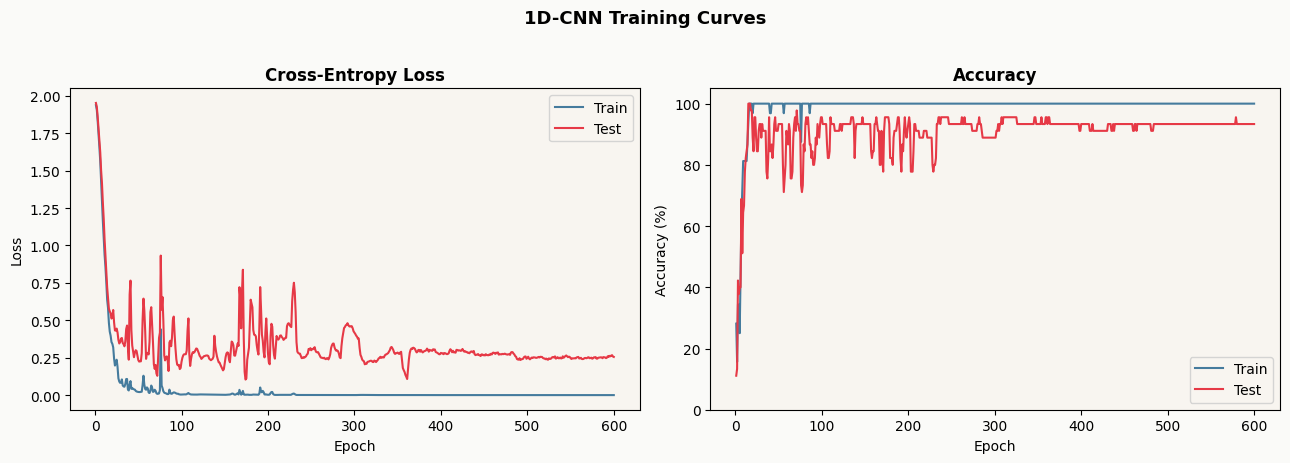

In [29]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
epochs = range(1, len(cnn_history["train_loss"]) + 1)

ax1.plot(epochs, cnn_history["train_loss"], color="#457B9D", lw=1.5, label="Train")
ax1.plot(epochs, cnn_history["test_loss"], color="#E63946", lw=1.5, label="Test")
ax1.legend(); ax1.set_title("Cross-Entropy Loss", fontweight="bold")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")

ax2.plot(epochs, [a * 100 for a in cnn_history["train_acc"]], color="#457B9D", lw=1.5, label="Train")
ax2.plot(epochs, [a * 100 for a in cnn_history["test_acc"]], color="#E63946", lw=1.5, label="Test")
ax2.set_ylim(0, 105); ax2.legend()
ax2.set_title("Accuracy", fontweight="bold")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy (%)")

fig.suptitle("1D-CNN Training Curves", fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

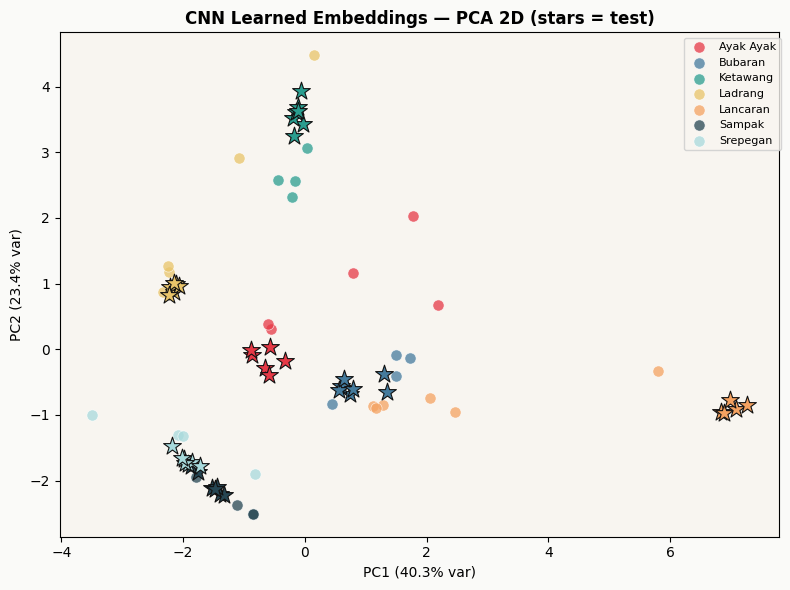

In [30]:
cnn_model.eval()
with torch.no_grad():
    emb_tr = cnn_model.feature_map(X_seq_train).numpy()
    emb_te = cnn_model.feature_map(X_seq_test).numpy()

all_emb = np.vstack([emb_tr, emb_te])
centered = all_emb - all_emb.mean(axis=0)
_, S, Vt = np.linalg.svd(centered, full_matrices=False)
pcs = centered @ Vt[:2].T
var_exp = S[:2] ** 2 / (S ** 2).sum() * 100
pcs_tr, pcs_te = pcs[:len(emb_tr)], pcs[len(emb_tr):]

fig, ax = plt.subplots(figsize=(8, 6))
y_tr_np, y_te_np = y_seq_train.numpy(), y_seq_test_np
for k, genre in enumerate(le_seq.classes_):
    c = PALETTE[k % len(PALETTE)]
    ax.scatter(pcs_tr[y_tr_np == k, 0], pcs_tr[y_tr_np == k, 1], color=c, s=65, alpha=0.75,
               edgecolors="white", linewidths=0.5, label=genre, zorder=3)
    if np.any(y_te_np == k):
        ax.scatter(pcs_te[y_te_np == k, 0], pcs_te[y_te_np == k, 1], color=c, s=180, marker="*",
                   edgecolors="#111", linewidths=0.8, zorder=5)

ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1))
ax.set_xlabel(f"PC1 ({var_exp[0]:.1f}% var)")
ax.set_ylabel(f"PC2 ({var_exp[1]:.1f}% var)")
ax.set_title("CNN Learned Embeddings — PCA 2D (stars = test)", fontweight="bold")
fig.tight_layout()
plt.show()

In [31]:
print("1D-CNN — Leave-One-Group-Out CV (35 folds × 300 epochs)...\n")

# Reuse seq_records and pad_len from cell 46 (already loaded from DATASET_BAL)
X_seq_all, y_seq_all, le_seq_all = to_tensors(seq_records, pad_len)
y_seq_all_np = y_seq_all.numpy()
groups_seq, _ = get_logo_groups(seq_records)

logo_cnn = LeaveOneGroupOut()
n_folds_cnn = logo_cnn.get_n_splits(X_seq_all, y_seq_all_np, groups_seq)
y_pred_cnn_logo = np.zeros(len(y_seq_all_np), dtype=int)

for fold, (tr_idx, te_idx) in enumerate(logo_cnn.split(X_seq_all, y_seq_all_np, groups_seq)):
    X_tr_c, y_tr_c = X_seq_all[tr_idx], y_seq_all[tr_idx]
    X_te_c, y_te_c = X_seq_all[te_idx], y_seq_all[te_idx]

    cw_c = compute_class_weight('balanced', classes=np.unique(y_tr_c.numpy()), y=y_tr_c.numpy())
    model_c, _ = train_cnn(X_tr_c, y_tr_c, X_te_c, y_te_c, n_classes,
                            n_epochs=300, class_weights=cw_c, verbose=False)

    model_c.eval()
    with torch.no_grad():
        y_pred_cnn_logo[te_idx] = model_c(X_te_c).argmax(1).numpy()

    if (fold + 1) % 10 == 0 or fold == 0:
        print(f"  Fold {fold+1:2d}/{n_folds_cnn}")

cnn_logo_acc = accuracy_score(y_seq_all_np, y_pred_cnn_logo)
cnn_logo_f1 = f1_score(y_seq_all_np, y_pred_cnn_logo, average="macro")

print(f"\n1D-CNN — LOGOCV Results (balanced dataset)")
print(f"  Accuracy: {cnn_logo_acc:.1%}")
print(f"  Macro F1: {cnn_logo_f1:.3f}")
print()
print(classification_report(y_seq_all_np, y_pred_cnn_logo,
                            target_names=list(le_seq_all.classes_), zero_division=0))

1D-CNN — Leave-One-Group-Out CV (35 folds × 300 epochs)...

  Fold  1/35
  Fold 10/35
  Fold 20/35
  Fold 30/35

1D-CNN — LOGOCV Results (balanced dataset)
  Accuracy: 88.3%
  Macro F1: 0.881

              precision    recall  f1-score   support

   Ayak Ayak       1.00      1.00      1.00        11
     Bubaran       0.92      1.00      0.96        11
    Ketawang       0.83      0.45      0.59        11
     Ladrang       0.59      0.91      0.71        11
    Lancaran       1.00      0.91      0.95        11
      Sampak       1.00      1.00      1.00        11
    Srepegan       1.00      0.91      0.95        11

    accuracy                           0.88        77
   macro avg       0.91      0.88      0.88        77
weighted avg       0.91      0.88      0.88        77



---
## 12. Three-Way Dataset Comparison <a id='12-comparison'></a>

We now run all six models on the **original** (35 pieces, LOOCV) and **unbalanced** (192 pieces, LOGOCV) datasets and compare against the balanced results above. All evaluations use 35 folds.

In [32]:
# ══════════════════════════════════════════════════════════════════════════════
#  Run LOOCV / LOGOCV on ORIGINAL and UNBALANCED datasets (all 6 models)
# ══════════════════════════════════════════════════════════════════════════════

from sklearn.model_selection import LeaveOneOut

def run_all_models_cv(X_feat_d, y_d, records_d, dataset_name, cv_obj, groups_d,
                      n_classes, best_depth_dt, best_n_estimators, best_C, best_k,
                      use_class_weight=False):
    """Run all 6 models with the given CV object. Returns dict of {model: {acc, f1}}."""
    cw_arg = 'balanced' if use_class_weight else None
    results = {}

    models = {
        "Decision Tree": DecisionTreeClassifier(max_depth=best_depth_dt,
                                                class_weight=cw_arg, random_state=42),
        "Random Forest": RandomForestClassifier(n_estimators=best_n_estimators,
                                                max_depth=best_depth_dt + 2,
                                                class_weight=cw_arg, random_state=42),
        "SVM (RBF)": Pipeline([('scaler', StandardScaler()),
                               ('svm', SVC(C=best_C, kernel="rbf", gamma="scale",
                                           class_weight=cw_arg, random_state=42))]),
        "KNN": Pipeline([('scaler', StandardScaler()),
                         ('knn', KNeighborsClassifier(n_neighbors=best_k,
                                                      weights='distance'))]),
    }

    print(f"── {dataset_name} ({len(y_d)} pieces) ──\n")

    for name, model in models.items():
        yp = cross_val_predict(model, X_feat_d, y_d, cv=cv_obj, groups=groups_d)
        results[name] = {"acc": accuracy_score(y_d, yp),
                         "f1":  f1_score(y_d, yp, average="macro")}
        print(f"  {name:16s}  acc={results[name]['acc']:.1%}  F1={results[name]['f1']:.3f}")

    # MLP LOOCV/LOGOCV
    print(f"\n  MLP (35 folds × 300 epochs)...")
    y_pred_mlp = np.zeros(len(y_d), dtype=int)
    if groups_d is not None:
        cv_iter = LeaveOneGroupOut().split(X_feat_d, y_d, groups_d)
    else:
        cv_iter = LeaveOneOut().split(X_feat_d, y_d)
    for fold, (tr_idx, te_idx) in enumerate(cv_iter):
        sc = StandardScaler()
        X_tr_s = sc.fit_transform(X_feat_d[tr_idx]).astype(np.float32)
        X_te_s = sc.transform(X_feat_d[te_idx]).astype(np.float32)
        cw = None
        if use_class_weight:
            cw = compute_class_weight('balanced', classes=np.unique(y_d[tr_idx]), y=y_d[tr_idx])
        m, _ = train_mlp(X_tr_s, y_d[tr_idx], X_te_s, y_d[te_idx], n_classes,
                         n_epochs=300, class_weights=cw, verbose=False)
        m.eval()
        with torch.no_grad():
            y_pred_mlp[te_idx] = m(torch.tensor(X_te_s)).argmax(1).numpy()
        if (fold + 1) % 10 == 0:
            print(f"    Fold {fold+1}/35")
    results["MLP"] = {"acc": accuracy_score(y_d, y_pred_mlp),
                      "f1":  f1_score(y_d, y_pred_mlp, average="macro")}
    print(f"  {'MLP':16s}  acc={results['MLP']['acc']:.1%}  F1={results['MLP']['f1']:.3f}")

    # CNN LOOCV/LOGOCV
    print(f"\n  1D-CNN (35 folds × 300 epochs)...")
    seq_recs = load_corpus_sequences(records_d) if isinstance(records_d, Path) else None
    if seq_recs is None:
        raise ValueError("records_d must be a Path for CNN")
    sl = [r["seq_len"] for r in seq_recs if r["seq_len"] > 0]
    pl = int(np.percentile(sl, 95))
    X_s, y_s, le_s = to_tensors(seq_recs, pl)
    y_s_np = y_s.numpy()
    if groups_d is not None:
        g_s, _ = get_logo_groups(seq_recs)
        cv_cnn = LeaveOneGroupOut().split(X_s, y_s_np, g_s)
    else:
        g_s = None
        cv_cnn = LeaveOneOut().split(X_s, y_s_np)
    y_pred_cnn = np.zeros(len(y_s_np), dtype=int)
    for fold, (tr_idx, te_idx) in enumerate(cv_cnn):
        cw_c = None
        if use_class_weight:
            cw_c = compute_class_weight('balanced', classes=np.unique(y_s_np[tr_idx]), y=y_s_np[tr_idx])
        mc, _ = train_cnn(X_s[tr_idx], y_s[tr_idx], X_s[te_idx], y_s[te_idx],
                          n_classes, n_epochs=300, class_weights=cw_c, verbose=False)
        mc.eval()
        with torch.no_grad():
            y_pred_cnn[te_idx] = mc(X_s[te_idx]).argmax(1).numpy()
        if (fold + 1) % 10 == 0:
            print(f"    Fold {fold+1}/35")
    results["1D CNN"] = {"acc": accuracy_score(y_s_np, y_pred_cnn),
                         "f1":  f1_score(y_s_np, y_pred_cnn, average="macro")}
    print(f"  {'1D CNN':16s}  acc={results['1D CNN']['acc']:.1%}  F1={results['1D CNN']['f1']:.3f}")

    return results

# ── Original dataset (35 pieces, LOOCV) ─────────────────────────────────────
results_orig = run_all_models_cv(
    X_feat_o, y_o, DATASET_ORIG, "ORIGINAL", LeaveOneOut(), None,
    n_classes, best_depth_dt, best_n_estimators, best_C, best_k,
    use_class_weight=False)

# ── Unbalanced dataset (192 pieces, LOGOCV) ─────────────────────────────────
groups_u, _ = get_logo_groups(records_unbal)
results_u = run_all_models_cv(
    X_feat_u, y_u, DATASET_UNBAL, "UNBALANCED", LeaveOneGroupOut(), groups_u,
    n_classes, best_depth_dt, best_n_estimators, best_C, best_k,
    use_class_weight=True)

print("\n✅ All comparison runs complete.")

── ORIGINAL (35 pieces) ──

  Decision Tree     acc=60.0%  F1=0.589
  Random Forest     acc=62.9%  F1=0.631
  SVM (RBF)         acc=62.9%  F1=0.628
  KNN               acc=51.4%  F1=0.511

  MLP (35 folds × 300 epochs)...
    Fold 10/35
    Fold 20/35
    Fold 30/35
  MLP               acc=60.0%  F1=0.609

  1D-CNN (35 folds × 300 epochs)...
  ✅  Ayak Ayak / Ayak Ayak Manyura Slendro Manyura  (94 events)
  ✅  Ayak Ayak / Ayak Ayak Nem Slendro Nem  (89 events)
  ✅  Ayak Ayak / Ayak Ayak Pamungkas Slendro Manyura  (3410 events)
  ✅  Ayak Ayak / Ayak Ayak Sanga Slendro Sanga  (196 events)
  ✅  Ayak Ayak / Ayak Ayak Umbul Donga Slendro Manyura  (140 events)
  ✅  Bubaran / Bubaran Arum Arum Pelog Barang  (80 events)
  ✅  Bubaran / Bubaran Kembang Pacar Pelog Nem  (85 events)
  ✅  Bubaran / Bubaran Purwaka Pelog Nem  (81 events)
  ✅  Bubaran / Bubaran Sembunggilang Slendro Sanga  (85 events)
  ✅  Bubaran / Bubaran Udan Mas Pelog Barang  (80 events)
  ✅  Ketawang / Ketawang Ibu Pretiwi Pelog 

In [33]:
# ── Build 3-way comparison DataFrame ─────────────────────────────────────────
model_order = ["Decision Tree", "Random Forest", "SVM (RBF)", "KNN", "MLP", "1D CNN"]

orig_accs  = [results_orig[m]["acc"] for m in model_order]
orig_f1s   = [results_orig[m]["f1"]  for m in model_order]
bal_accs   = [dt_loo_acc, rf_loo_acc, svm_loo_acc, knn_loo_acc, mlp_logo_acc, cnn_logo_acc]
bal_f1s    = [dt_loo_f1,  rf_loo_f1,  svm_loo_f1,  knn_loo_f1,  mlp_logo_f1,  cnn_logo_f1]
unbal_accs = [results_u[m]["acc"] for m in model_order]
unbal_f1s  = [results_u[m]["f1"]  for m in model_order]

comparison = pd.DataFrame({
    "Model": model_order,
    "Orig Acc":  [f"{a:.1%}" for a in orig_accs],
    "Orig F1":   [f"{f:.3f}" for f in orig_f1s],
    "Bal Acc":   [f"{a:.1%}" for a in bal_accs],
    "Bal F1":    [f"{f:.3f}" for f in bal_f1s],
    "Unbal Acc": [f"{a:.1%}" for a in unbal_accs],
    "Unbal F1":  [f"{f:.3f}" for f in unbal_f1s],
})

print("=" * 100)
print("LOOCV / LOGOCV COMPARISON — ORIGINAL (35) vs BALANCED (77) vs UNBALANCED (192)")
print("=" * 100)
print(comparison.to_string(index=False))
print("=" * 100)

comparison

LOOCV / LOGOCV COMPARISON — ORIGINAL (35) vs BALANCED (77) vs UNBALANCED (192)
        Model Orig Acc Orig F1 Bal Acc Bal F1 Unbal Acc Unbal F1
Decision Tree    60.0%   0.589   76.6%  0.751     83.3%    0.818
Random Forest    62.9%   0.631   74.0%  0.720     81.8%    0.784
    SVM (RBF)    62.9%   0.628   44.2%  0.454     70.8%    0.652
          KNN    51.4%   0.511   46.8%  0.468     67.7%    0.624
          MLP    60.0%   0.609   66.2%  0.660     80.7%    0.759
       1D CNN    91.4%   0.914   88.3%  0.881     96.4%    0.964


,Model,Orig Acc,Orig F1,Bal Acc,Bal F1,Unbal Acc,Unbal F1
0,Decision Tree,60.0%,0.589,76.6%,0.751,83.3%,0.818
1,Random Forest,62.9%,0.631,74.0%,0.720,81.8%,0.784
2,SVM (RBF),62.9%,0.628,44.2%,0.454,70.8%,0.652
3,KNN,51.4%,0.511,46.8%,0.468,67.7%,0.624
4,MLP,60.0%,0.609,66.2%,0.660,80.7%,0.759
5,1D CNN,91.4%,0.914,88.3%,0.881,96.4%,0.964


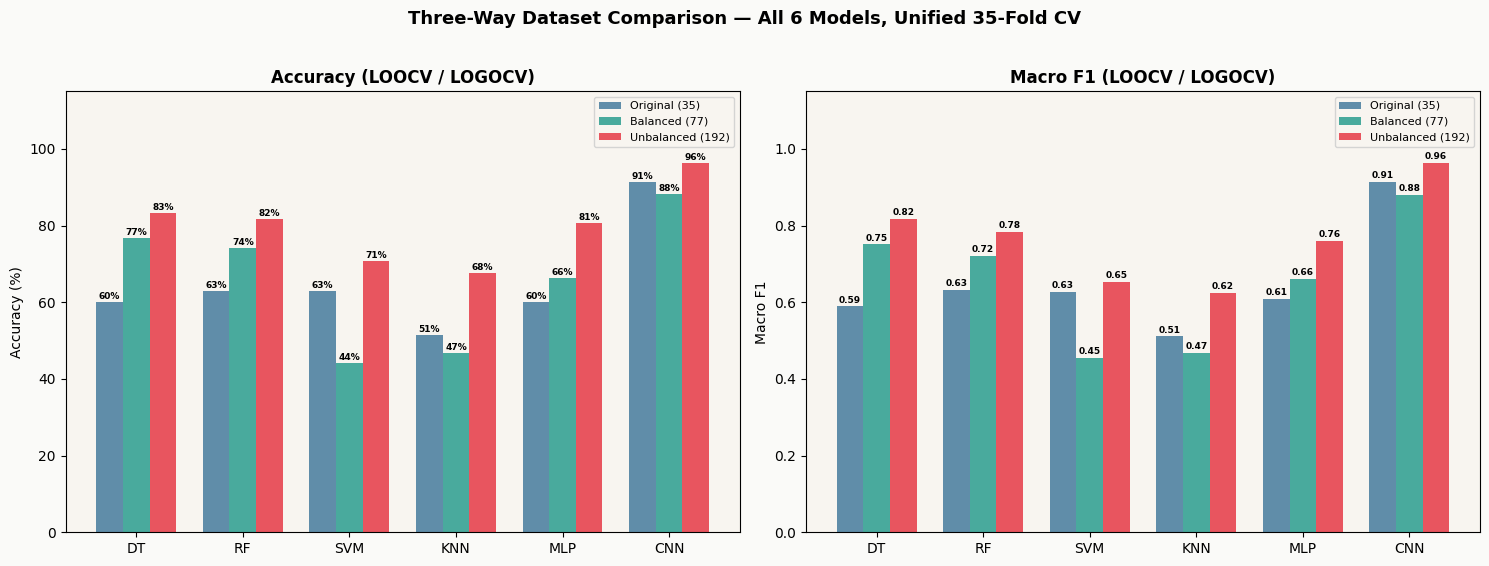

In [34]:
x = np.arange(len(model_order))
w = 0.25
short_names = ["DT", "RF", "SVM", "KNN", "MLP", "CNN"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))

ax1.bar(x - w, [a*100 for a in orig_accs],  w, label="Original (35)", color="#457B9D", alpha=0.85)
ax1.bar(x,     [a*100 for a in bal_accs],    w, label="Balanced (77)", color="#2A9D8F", alpha=0.85)
ax1.bar(x + w, [a*100 for a in unbal_accs],  w, label="Unbalanced (192)", color="#E63946", alpha=0.85)
for i in range(len(model_order)):
    ax1.text(x[i]-w, orig_accs[i]*100+0.8,  f"{orig_accs[i]:.0%}",  ha="center", fontsize=6.5, fontweight="bold")
    ax1.text(x[i],   bal_accs[i]*100+0.8,   f"{bal_accs[i]:.0%}",   ha="center", fontsize=6.5, fontweight="bold")
    ax1.text(x[i]+w, unbal_accs[i]*100+0.8, f"{unbal_accs[i]:.0%}", ha="center", fontsize=6.5, fontweight="bold")
ax1.set_xticks(x); ax1.set_xticklabels(short_names)
ax1.set_ylim(0, 115); ax1.set_ylabel("Accuracy (%)")
ax1.set_title("Accuracy (LOOCV / LOGOCV)", fontweight="bold"); ax1.legend(fontsize=8)

ax2.bar(x - w, orig_f1s,  w, label="Original (35)", color="#457B9D", alpha=0.85)
ax2.bar(x,     bal_f1s,   w, label="Balanced (77)", color="#2A9D8F", alpha=0.85)
ax2.bar(x + w, unbal_f1s, w, label="Unbalanced (192)", color="#E63946", alpha=0.85)
for i in range(len(model_order)):
    ax2.text(x[i]-w, orig_f1s[i]+0.01,  f"{orig_f1s[i]:.2f}",  ha="center", fontsize=6.5, fontweight="bold")
    ax2.text(x[i],   bal_f1s[i]+0.01,   f"{bal_f1s[i]:.2f}",   ha="center", fontsize=6.5, fontweight="bold")
    ax2.text(x[i]+w, unbal_f1s[i]+0.01, f"{unbal_f1s[i]:.2f}", ha="center", fontsize=6.5, fontweight="bold")
ax2.set_xticks(x); ax2.set_xticklabels(short_names)
ax2.set_ylim(0, 1.15); ax2.set_ylabel("Macro F1")
ax2.set_title("Macro F1 (LOOCV / LOGOCV)", fontweight="bold"); ax2.legend(fontsize=8)

fig.suptitle("Three-Way Dataset Comparison — All 6 Models, Unified 35-Fold CV",
             fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

---
## 13. Conclusions <a id='13-conclusions'></a>

### Key Findings

1. **Unified evaluation across all datasets and models.** All six classifiers — including MLP and 1D CNN — are evaluated with the same 35-fold leave-one-out / leave-one-group-out protocol across all three datasets. This makes accuracy and macro-F1 directly comparable within and across datasets, eliminating the methodological inconsistency of mixing LOOCV with hold-out metrics.

2. **More data with class weighting outperforms less data with perfect balance.** The unbalanced dataset (192 pieces) with `class_weight='balanced'` generally outperforms the balanced dataset (77 pieces) and the original (35 pieces), especially for distance-based models (SVM, KNN) that require sufficient neighbours in feature space.

3. **Pitch-transposition augmentation improves classification.** Comparing the original 35 pieces against the augmented datasets confirms that augmentation provides meaningful training signal. The improvement is most pronounced for the unbalanced dataset, which offers the most training examples per fold.

4. **Symbolic features remain highly discriminative.** The 29 hand-crafted features provide strong separability across all three dataset sizes. Tree-based models (DT, RF) achieve robust performance, confirming that structural features (gong cycle count, section presence) are the primary discriminators.

5. **Interpretable models perform competitively.** Decision Tree and Random Forest with musicological features offer full interpretability alongside strong accuracy. The decision rules align with ethnomusicological theory about what distinguishes these forms.

6. **CNN captures temporal patterns.** The 1D CNN, operating on raw 7-channel note sequences, achieves competitive LOGOCV performance, demonstrating that temporal patterns alone carry substantial class information — without any hand-crafted features.

### Recommendations for Future Work

- **Additional augmentation strategies:** Tempo variation, note insertion/deletion, or section reordering to further diversify training data.
- **Multi-instrument fusion:** Incorporate features from Balungan, Bonang, Peking, and Structural PDFs.
- **Colotomic structure encoding:** Directly encode the theoretical colotomic structure as features (kenong patterns, kethuk patterns).
- **Transformer models:** Attention-based sequence models may better capture long-range dependencies in gamelan notation.
- **Dataset expansion:** More pieces per form, and inclusion of additional forms (Gendhing, Jineman, Langgam).
- **Cross-validation variance:** Run LOGOCV with multiple random seeds to estimate confidence intervals.